# 04 · Contexto del estudiante en el tiempo — Pruebas APRENDER y Relevamiento Anual

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/santiagoriverti/analisis_pruebas_aprender/blob/main/04_contexto.ipynb)

Análisis **descriptivo** de cómo cambió el **contexto de los estudiantes** que rinden APRENDER, **dentro de cada cohorte
comparable** (misma nivel, grado y cobertura censal), y de las trayectorias escolares del **Relevamiento Anual (RA)**.

| Cohorte | Operativos |
|---|---|
| Primaria 6° grado (censal) | 2016 · 2018 · 2021 · 2023 · 2025 |
| Secundaria 5°/6° año (censal) | 2016 · 2017 · 2019 · 2022 · 2024 |

**Qué se mide (APRENDER, cuestionario complementario del estudiante):**
- **Trayectoria:** repitencia declarada, asistencia al jardín (desde sala de 3), sobreedad.
- **Hogar:** nivel educativo de la madre y del padre, libros en el hogar.
- **Acceso digital:** internet y computadora en el hogar, celular propio.
- **Trabajo y cuidados:** ayudar en el trabajo de familiares, trabajar para otros, cuidar familiares.

Cada indicador es el **% de estudiantes** (conteos ponderados del cuestionario `Solo CC`) que responde la opción indicada,
emparejando la **misma pregunta** entre años aunque cambie su código. Se abre por **país, sector, ámbito y provincia**.

**Cómo leerlo (importante):**
- Del denominador se excluyen las respuestas en **blanco, multimarca, sin dato y "No sé"**. Algunos años no ofrecen la
  opción "No sé" (p. ej. nivel educativo de la madre desde 2022/2023). El % que responde "No sé" figura en la sección 2
  (`pct_no_se`).
- Cuando la **redacción, el período de referencia o el formato** de la pregunta cambia (p. ej. "la semana pasada" frente a
  "habitualmente", o "marcá si hay" frente a "¿cuántos hay?"), **la línea se corta**: esos puntos no forman una serie.
  También se corta cuando **más del 10 % responde "No sé"** en un año y la opción no existe en otro (libros hasta
  2019/2021; nivel educativo de la madre en Primaria hasta 2021): al excluirlos cambia la base de comparación.
  El detalle de qué pregunta se usó cada año está en la sección 2 y en la hoja `preguntas_por_anio`.
- **Primaria 2025 no tiene diccionario de variables** y el cuestionario está renumerado. Jardín (`ap06`), repitencia (`ap07`)
  y libros (`ap24`) se identifican sin ambigüedad por sus opciones. Las preguntas de **acceso digital y de trabajo** tienen
  varias candidatas con distribución parecida: **no se imputan** y quedan sin dato en 2025.
- **Secundaria 2016** registra los objetos del hogar solo con la opción "Sí" (sin "No"): no permite calcular porcentajes.
- Son bases **agregadas**: no hay cruce por estudiante con el desempeño. **Sin econometría.**

**RA (2011–2025):** sobreedad, repitencia y abandono **por año de estudio**, egresados y brecha **mujeres/varones**.
La base *Trayectoria* del año *t* informa el **ciclo lectivo t−1**.

Requiere haber corrido antes `00_consolidacion.ipynb` (lee de *Mi unidad/`pruebas_aprender`*). No necesita el 01, 02 ni 03.

---
## 0 · Setup y carga

In [1]:
import os, re, glob, shutil, textwrap, unicodedata
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.lines import Line2D
import pyarrow.dataset as pads

def in_colab():
    try:
        import google.colab  # noqa
        return True
    except ImportError:
        return False

if in_colab():
    from google.colab import drive
    drive.mount('/content/drive')
    OUT = '/content/drive/MyDrive/pruebas_aprender/parquet'
else:
    OUT = os.path.join(os.getcwd(), 'datos_consolidados')
assert os.path.isdir(os.path.join(OUT, 'aprender_long')), (
    f'No encuentro el dataset en {OUT}. Corré primero 00_consolidacion.ipynb.')

# Paleta validada: fondo claro, grilla y ejes recesivos; azul/naranja para dos grupos; azul/rojo para cambios (+/−);
# rampa azul (claro → oscuro) para magnitudes en los mapas de calor
SUPERFICIE, TINTA, TINTA_2, TENUE, GRILLA, EJE = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
AZUL, NARANJA, ROJO, NEUTRO = '#2a78d6', '#eb6834', '#e34948', '#f0efec'
DIVERGENTE = LinearSegmentedColormap.from_list('divergente', [ROJO, NEUTRO, AZUL])
SECUENCIAL = LinearSegmentedColormap.from_list('secuencial', ['#f4f8fe', '#cde2fb', '#86b6ef', '#2a78d6', '#184f95', '#0d366b'])
plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': SUPERFICIE, 'axes.facecolor': SUPERFICIE, 'savefig.facecolor': SUPERFICIE,
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'DejaVu Sans', 'Arial'],
    'text.color': TINTA, 'axes.labelcolor': TINTA_2, 'axes.edgecolor': EJE, 'axes.titlecolor': TINTA,
    'xtick.color': TENUE, 'ytick.color': TINTA_2, 'axes.grid': True, 'grid.color': GRILLA, 'grid.linewidth': 0.6,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.axisbelow': True})

# Carpeta de salida: gráficos a 300 dpi + Excel con las tablas (se descargan en un zip al final)
GRAF = os.path.abspath('graficos_contexto'); os.makedirs(GRAF, exist_ok=True)
def guardar(fig, nombre):
    fig.savefig(os.path.join(GRAF, nombre + '.png'), dpi=300, bbox_inches='tight')
    return fig
def nota(fig, texto, y=-0.01):
    fig.text(0.01, y, texto, fontsize=8, color=TENUE, ha='left', va='top')
FUENTE_AP = 'Fuente: Pruebas APRENDER, cuestionario complementario del estudiante (Secretaría de Educación). % ponderado sin blancos ni "No sé".'
FUENTE_RA = 'Fuente: Relevamiento Anual (RA), Secretaría de Educación.'
print('Datos consolidados en:', OUT)
print('Salidas (gráficos 300 dpi + Excel) en:', GRAF)

Datos consolidados en: C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\datos_consolidados
Salidas (gráficos 300 dpi + Excel) en: C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\graficos_contexto


---
## 1 · Funciones y especificación de indicadores
Cada indicador define, **por año**, el código de la pregunta, las opciones que cuentan en el numerador (o las que se
excluyen) y una etiqueta de **redacción**: años consecutivos con la misma etiqueta forman una serie; si la etiqueta
cambia, la línea se corta. Los `assert` verifican que cada opción exista en los datos (si el cuestionario cambia, falla).

In [2]:
def _n(s):
    s = unicodedata.normalize('NFKD', str(s)).encode('ascii', 'ignore').decode().lower()
    return re.sub(r'[^a-z0-9]+', ' ', s).strip()

# Nombres de provincia homogéneos entre años y entre APRENDER y el Relevamiento Anual
PROV_ALIAS = {'buenos aires': 'Buenos Aires', 'ciudad autonoma de buenos aires': 'CABA', 'ciudad de buenos aires': 'CABA',
              'tierra del fuego': 'Tierra del Fuego', 'tierra del fuego antartida e islas del atlantico sur': 'Tierra del Fuego'}
def norm_prov(s):
    return PROV_ALIAS.get(_n(s), str(s).strip())
SECTOR = {'Estatal': 'Estatal', 'Privado': 'Privado', 'Privada': 'Privado'}

COHORTES = {'Primaria 6°':     dict(nivel='Primaria',   grado='6 grado', anios=[2016, 2018, 2021, 2023, 2025]),
            'Secundaria 5-6°': dict(nivel='Secundaria', grado='5-6 año', anios=[2016, 2017, 2019, 2022, 2024])}
BLANCOS = {'Blanco', 'No_disponible', 'Multimarca', 'Dato_faltante'}
NO_SABE = re.compile(r'^(\d+_)?No_s[eé]$')

def archivos(anio):
    return sorted(glob.glob(os.path.join(OUT, 'aprender_long', f'anio={anio}', '*.parquet')))

_cache_cc = {}
def cuestionario(coh, anio, codigos):
    """Cuestionario Solo CC del operativo censal, solo con los códigos pedidos (para ahorrar memoria)."""
    k = (coh, anio)
    if k not in _cache_cc:
        c = COHORTES[coh]
        f = ((pads.field('area') == 'Solo CC') & (pads.field('cobertura') == 'Censal')
             & (pads.field('nivel') == c['nivel']) & (pads.field('grado') == c['grado']))
        d = (pads.dataset(archivos(anio), format='parquet')
             .to_table(filter=f, columns=['jurisdiccion', 'sector', 'ambito', 'variable', 'valor']).to_pandas())
        sp = d.variable.str.split('_', n=1)
        d['codigo'], d['opcion'] = sp.str[0], sp.str[1]
        d = d[d.codigo.isin(codigos)].copy()
        d['provincia'] = d.jurisdiccion.map(norm_prov)
        d['sector'] = d.sector.map(SECTOR)
        _cache_cc[k] = d.drop(columns=['jurisdiccion', 'variable'])
    return _cache_cc[k]

def S(codigo, r='misma pregunta', **kw):
    """Especificación de un año: código, etiqueta de redacción y num= (opciones) | excluir= | prefijo= | solo_nosabe=True."""
    return dict(codigo=codigo, r=r, **kw)

def conteos(d, s):
    """Numerador y denominador ponderados por provincia × sector × ámbito para una especificación."""
    x = d[d.codigo == s['codigo']]
    assert len(x), f"código {s['codigo']} sin datos"
    op = x.opcion
    if s.get('prefijo'):
        m_pref = op.str.startswith(s['prefijo'])
        x, op = x[m_pref], op[m_pref].str[len(s['prefijo']):]
    valido = ~op.isin(BLANCOS)
    nosabe = op.str.match(NO_SABE)
    if s.get('solo_nosabe'):
        assert nosabe.any(), f"{s['codigo']}: sin opción 'No sé'"
        num = nosabe
    else:
        valido &= ~nosabe
        ops = set(op[valido])
        if 'excluir' in s:
            assert set(s['excluir']) <= ops, f"{s['codigo']}: opciones a excluir inexistentes {set(s['excluir']) - ops}"
            num = ~op.isin(s['excluir'])
        elif callable(s['num']):
            num = op.map(s['num']).astype(bool)
        else:
            assert set(s['num']) <= ops, f"{s['codigo']} {s.get('prefijo') or ''}: opciones inexistentes {set(s['num']) - ops}"
            num = op.isin(s['num'])
    num &= valido
    assert num.any(), f"{s['codigo']}: numerador vacío"
    t = x.assign(num=x.valor.where(num, 0.0), den=x.valor.where(valido, 0.0))
    return t.groupby(['provincia', 'sector', 'ambito'])[['num', 'den']].sum().reset_index()

def pct_nosabe(d, s):
    """% del país que responde "No sé" (sobre respuestas válidas); 0 si la pregunta no ofrece esa opción."""
    x = d[d.codigo == s['codigo']]
    op = x.opcion
    if s.get('prefijo'):
        m_pref = op.str.startswith(s['prefijo'])
        x, op = x[m_pref], op[m_pref].str[len(s['prefijo']):]
    valido = ~op.isin(BLANCOS)
    return 100 * x.valor[valido & op.str.match(NO_SABE)].sum() / x.valor[valido].sum()
UMBRAL_NOSABE = 10   # si más del 10 % responde "No sé", excluirlo cambia la base: ese año forma otro tramo

NO_REALICE_22, NO_HICE_24 = {'No_realicé_esta_tarea'}, {'No_hice_estas_actividades'}
SOBRE = lambda o: 'de_sobreedad' in o

In [3]:
# (tema, indicador, {año: especificación}); los años ausentes no tienen una pregunta equivalente identificable
IND = {
 'Primaria 6°': [
  ('Trayectoria', 'Repitió algún grado', {
      2016: S('Ap12', excluir={'1_Nunca'}), 2018: S('ap17', excluir={'No'}), 2021: S('ap25', excluir={'No'}),
      2023: S('ap22', excluir={'No'}), 2025: S('ap07', excluir={'No'})}),
  ('Trayectoria', 'Fue al jardín desde sala de 3 o antes', {
      2016: S('Ap11', num={'1_Sí_fui_al_jardín_antes_de_los_cuatro_años'}), 2018: S('ap16', num={'Sí_fui_al_jardín_antes_de_los_cuatro_años'}),
      2021: S('ap24', num={'Sí_fui_al_jardín_antes_de_los_4_años'}), 2023: S('ap21', num={'Sí_fui_al_jardín_desde_sala_de_3_o_antes'}),
      2025: S('ap06', num={'Sí_fui_al_jardín_desde_sala_de_3_o_antes'})}),
  ('Trayectoria', 'No fue al jardín', {
      2016: S('Ap11', num={'4_No_fui_al_jardín'}), 2018: S('ap16', num={'No_fui_al_jardín'}), 2021: S('ap24', num={'No_fui_al_jardín'}),
      2023: S('ap21', num={'No_no_fui_al_jardín'}), 2025: S('ap06', num={'No_no_fui_al_jardín'})}),
  ('Trayectoria', 'Con sobreedad (1 año o más)', {
      2021: S('sobreedad', num=SOBRE), 2023: S('sobreedad', num=SOBRE), 2025: S('sobreedad', num=SOBRE)}),
  ('Hogar', 'Madre con secundaria completa o más', {
      2016: S('Ap7', num={'Fue_a_la_escuela_secundaria_y_la_completó', 'Estudio_el_nivel_terciario_o_en_una_universidad'}),
      2018: S('ap9', num={'Secundaria_completa', 'Universitario_o_terciario_incompleto', 'Universitario_o_terciario_completo'}),
      2021: S('Nivel', prefijo='Ed_Madre_', num={'Secundario_completo', 'Terciario_Universitario_incompleto', 'Terciario_Universitario_completo', 'Posgrado_especialización_maestría_doctorado_etc'}),
      2023: S('Nivel', prefijo='Ed_Madre_', num={'Secundaria_completa', 'Terciario_universitario_posgrado_incompleto', 'Terciario_universitario_posgrado_completo'}),
      2025: S('Nivel', prefijo='Ed_Madre_', num={'Secundaria_completa', 'Terciario_universitario_posgrado_incompleto', 'Terciario_universitario_posgrado_completo'})}),
  ('Hogar', 'Madre con terciario o universitario completo', {
      2018: S('ap9', num={'Universitario_o_terciario_completo'}),
      2021: S('Nivel', prefijo='Ed_Madre_', num={'Terciario_Universitario_completo', 'Posgrado_especialización_maestría_doctorado_etc'}),
      2023: S('Nivel', prefijo='Ed_Madre_', num={'Terciario_universitario_posgrado_completo'}),
      2025: S('Nivel', prefijo='Ed_Madre_', num={'Terciario_universitario_posgrado_completo'})}),
  ('Hogar', 'Padre con secundaria completa o más', {
      2016: S('Ap8', num={'Fue_a_la_escuela_secundaria_y_la_completó', 'Estudio_el_nivel_terciario_o_en_una_universidad'}),
      2018: S('ap10', num={'Secundaria_completa', 'Universitario_o_terciario_incompleto', 'Universitario_o_terciario_completo'}),
      2021: S('Nivel', prefijo='Ed_Padre_', num={'Secundario_completo', 'Terciario_Universitario_incomple', 'Terciario_Universitario_completo', 'Posgrado_especialización_maestría_doctorado_etc'}),
      2023: S('Nivel', prefijo='Ed_Padre_', num={'Secundaria_completa', 'Terciario_universitario_posgrado_incompleto', 'Terciario_universitario_posgrado_completo'}),
      2025: S('Nivel', prefijo='Ed_Padre_', num={'Secundaria_completa', 'Terciario_universitario_posgrado_incompleto', 'Terciario_universitario_posgrado_completo'})}),
  ('Hogar', 'No sabe el nivel educativo de la madre', {
      2016: S('Ap7', solo_nosabe=True), 2018: S('ap9', solo_nosabe=True), 2021: S('Nivel', prefijo='Ed_Madre_', solo_nosabe=True)}),
  ('Hogar', 'Más de 50 libros en el hogar', {
      2018: S('ap8', num={'De_51_a_100_libros', 'Más_de_100_libros'}), 2021: S('ap15', num={'De_51_a_100_libros', 'Más_de_100_libros'}),
      2023: S('ap10', num={'De_51_a_100_libros', 'Más_de_100_libros'}), 2025: S('ap24', num={'51_a_100_libros', 'Más_de_100_libros'})}),
  ('Hogar', 'Sin libros en el hogar', {
      2018: S('ap8', num={'No_hay_libros'}), 2021: S('ap15', num={'No_hay_libros'}),
      2023: S('ap10', num={'No_tengo_libros_en_formato_papel'}), 2025: S('ap24', num={'No_hay_libros'})}),
  ('Acceso digital', 'Internet en el hogar', {
      2016: S('Ap28j', num={'Si'}), 2018: S('ap7a', num={'Sí'}),
      2021: S('ap10c', 'marcar de una lista', num={'Si'}), 2023: S('ap09d', num={'Sí'})}),
  ('Acceso digital', 'Computadora en el hogar', {
      2018: S('ap7c', num={'Sí'}), 2021: S('ap11d', '¿cuántas hay?', excluir={'Ninguno'}), 2023: S('ap09i', num={'Sí'})}),
  ('Acceso digital', 'Celular propio', {
      2016: S('Ap29', num={'1_Sí'}), 2018: S('ap27a', num={'Sí'}), 2023: S('ap11', num={'Sí'})}),
  ('Trabajo y cuidados', 'Ayuda a familiares en su trabajo', {
      2016: S('Ap9a', 'la semana pasada', num={'Si'}), 2018: S('ap14', 'habitualmente', num={'Sí'}),
      2021: S('ap20a', 'habitualmente', num={'Si'}), 2023: S('ap07a', 'la semana pasada', excluir=NO_REALICE_22)}),
  ('Trabajo y cuidados', 'Trabaja para alguien que no es de su familia', {
      2016: S('Ap10', 'trabajó fuera de casa la semana pasada', num={'1_Sí'}), 2018: S('ap15', 'habitualmente, fuera de casa', num={'Sí'}),
      2021: S('ap20b', 'habitualmente', num={'Si'}), 2023: S('ap07b', 'la semana pasada', excluir=NO_REALICE_22)}),
  ('Trabajo y cuidados', 'Cuida a hermanos u otros familiares', {
      2016: S('Ap9b', 'la semana pasada, solo/a', num={'Si'}), 2018: S('ap13a', 'con qué frecuencia', excluir={'Nunca'}),
      2021: S('ap19a', 'con qué frecuencia', excluir={'Nunca'}), 2023: S('ap06a', 'la semana pasada', excluir=NO_REALICE_22)}),
 ],
 'Secundaria 5-6°': [
  ('Trayectoria', 'Repitió en la primaria', {
      2016: S('Ap15', excluir={'1_Nunca'}), 2017: S('ap20', excluir={'No'}), 2019: S('ap25', prefijo='01_', excluir={'No'}),
      2022: S('ap25a', excluir={'No'}), 2024: S('ap25a', excluir={'No'})}),
  ('Trayectoria', 'Repitió en la secundaria (algún año)', {
      2016: S('Ap16', excluir={'1_Nunca'}), 2017: S('ap21', excluir={'No'})}),
  ('Trayectoria', 'Repitió en el ciclo básico', {
      2019: S('ap25', prefijo='02_', excluir={'No'}), 2022: S('ap25b', excluir={'No'}), 2024: S('ap25b', excluir={'No'})}),
  ('Trayectoria', 'Fue al jardín desde sala de 3 o antes', {
      2016: S('Ap14', num={'1_Sí_fui_al_jardín_antes_de_los_cuatro_años'}), 2017: S('ap19', num={'Sí_fui_al_jardín_antes_de_los_cuatro_años'}),
      2019: S('ap24', num={'Sí_antes_de_los_cuatro_años'}), 2022: S('ap24', num={'Sí_desde_sala_de_3_años'}),
      2024: S('ap24', num={'Sí_desde_sala_de_3_o_antes'})}),
  ('Trayectoria', 'No fue al jardín', {
      2016: S('Ap14', num={'4_No_fui_al_jardín'}), 2017: S('ap19', num={'No_fui_al_jardín'}), 2019: S('ap24', num={'No_asistí'}),
      2022: S('ap24', num={'No_no_fui_al_jardín'}), 2024: S('ap24', num={'No_no_fui_al_jardín'})}),
  ('Trayectoria', 'Con sobreedad (1 año o más)', {
      2019: S('sobreedad', num=SOBRE), 2022: S('sobreedad', num=SOBRE), 2024: S('sobreedad', num=SOBRE)}),
  ('Hogar', 'Madre con secundaria completa o más', {
      2016: S('Ap7', num={'4_Terminó_la_escuela_secundaria', '5_Tiene_estudios_terciarios', '6_Tiene_estudios_universitarios'}),
      2017: S('ap10', num={'Secundaria_completa', 'Universitario_o_terciario_incompleto', 'Universitario_o_terciario_completo'}),
      2019: S('ap16', num={'Secundaria_completa', 'Educación_superior_terciaria', 'Educación_superior_universitaria', 'Posgrado'}),
      2022: S('Nivel', prefijo='Ed_Madre_', num={'Secundaria_completa', 'Terciario_universitario_posgrado_incompleto', 'Terciario_universitario_posgrado_completo'}),
      2024: S('Nivel', prefijo='Ed_Madre_', num={'Secundaria_completo', 'Terciariouniversitarioposgrado_incompleto', 'Terciariouniversitarioposgrado_completo'})}),
  ('Hogar', 'Madre con terciario o universitario completo', {
      2017: S('ap10', num={'Universitario_o_terciario_completo'}),
      2022: S('Nivel', prefijo='Ed_Madre_', num={'Terciario_universitario_posgrado_completo'}),
      2024: S('Nivel', prefijo='Ed_Madre_', num={'Terciariouniversitarioposgrado_completo'})}),
  ('Hogar', 'Padre con secundaria completa o más', {
      2016: S('Ap8', num={'4_Terminó_la_escuela_secundaria', '5_Tiene_estudios_terciarios', '6_Tiene_estudios_universitarios'}),
      2017: S('ap11', num={'Secundaria_completa', 'Universitario_o_terciario_incompleto', 'Universitario_o_terciario_completo'}),
      2019: S('ap17', num={'Secundaria_completa', 'Educación_superior_terciaria', 'Educación_superior_universitaria', 'Posgrado'}),
      2022: S('Nivel', prefijo='Ed_Padre_', num={'Secundaria_completa', 'Terciario_universitario_posgrado_incompleto', 'Terciario_universitario_posgrado_completo'}),
      2024: S('Nivel', prefijo='Ed_Padre_', num={'Secundaria_completo', 'Terciariouniversitarioposgrado_incompleto', 'Terciariouniversitarioposgrado_completo'})}),
  ('Hogar', 'No sabe el nivel educativo de la madre', {
      2016: S('Ap7', solo_nosabe=True), 2019: S('ap16', solo_nosabe=True)}),
  ('Hogar', 'Más de 50 libros en el hogar', {
      2017: S('ap9', num={'De_51_a_100_libros', 'Más_de_100_libros'}), 2019: S('ap15', num={'De_51_a_100_libros', 'Más_de_100_libros'}),
      2022: S('ap15', num={'De_51_a_100_libros', 'Más_de_100_libros'}), 2024: S('ap19', num={'De_51_a_100_libros', 'Más_de_100_libros'})}),
  ('Hogar', 'Sin libros en el hogar', {
      2017: S('ap9', num={'No_hay_libros'}), 2019: S('ap15', num={'No_hay_libros'}),
      2022: S('ap15', num={'No_tengo_libros_en_formato_papel'}), 2024: S('ap19', num={'No_hay_libros_en_formato_papel'})}),
  ('Acceso digital', 'Internet en el hogar', {
      2017: S('ap7d', num={'Sí'}), 2019: S('ap11', prefijo='08_', num={'Si'}), 2022: S('ap12k', num={'Sí'}), 2024: S('ap16k', num={'Sí'})}),
  ('Acceso digital', 'Computadora en el hogar', {
      2017: S('ap8b', num={'Sí'}), 2019: S('ap11', '¿cuántas hay?', prefijo='06_', excluir={'Ninguno'}),
      2022: S('ap12g', num={'Sí'}), 2024: S('ap16g', num={'Sí'})}),
  ('Acceso digital', 'Celular propio', {
      2016: S('Ap41', num={'1_Sí'}), 2017: S('ap46a', num={'Sí'}), 2019: S('ap12', num={'Sí'}), 2022: S('ap13', num={'Sí'}), 2024: S('ap16f', num={'Sí'})}),
  ('Trabajo y cuidados', 'Ayuda a familiares en su trabajo', {
      2016: S('Ap10a', 'la semana pasada', num={'Si'}), 2019: S('ap19', 'las últimas dos semanas', num={'Sí'}),
      2024: S('ap22c', 'la semana pasada', excluir=NO_HICE_24)}),
  ('Trabajo y cuidados', 'Trabaja para un empleador o no familiar', {
      2016: S('Ap11', 'trabajó fuera de casa la semana pasada', num={'1_Sí'}), 2017: S('ap17', 'habitualmente', num={'Sí'}),
      2022: S('ap19a', 'la semana pasada', excluir=NO_REALICE_22), 2024: S('ap22b', 'la semana pasada', excluir=NO_HICE_24)}),
  ('Trabajo y cuidados', 'Cuida a familiares sin ayuda', {
      2016: S('Ap10b', 'la semana pasada', num={'Si'}), 2017: S('ap15a', 'con qué frecuencia', excluir={'Nunca'}),
      2022: S('ap18b', 'la semana pasada', excluir=NO_REALICE_22), 2024: S('ap21b', 'la semana pasada', excluir=NO_HICE_24)}),
 ]}

# Diccionario usado para mostrar el texto de cada pregunta (2025 no tiene diccionario propio)
DIC_ANIO = {('Primaria 6°', 2016): (2016, 'Primaria'), ('Primaria 6°', 2018): (2018, 'General'), ('Primaria 6°', 2021): (2021, 'General'),
            ('Primaria 6°', 2023): (2023, 'General'), ('Secundaria 5-6°', 2016): (2016, 'Secundaria'),
            ('Secundaria 5-6°', 2017): (2017, 'Secundaria'), ('Secundaria 5-6°', 2019): (2019, 'General'),
            ('Secundaria 5-6°', 2022): (2022, 'General'), ('Secundaria 5-6°', 2024): (2024, 'Secundaria')}
dic = pd.read_parquet(os.path.join(OUT, 'diccionario_aprender.parquet'))
dic['cod'] = dic.variable.str.split('_').str[0].str.lower()

filas, preguntas = [], []
for coh, lista in IND.items():
    codigos = {s['codigo'] for _, _, sp in lista for s in sp.values()}
    for anio in COHORTES[coh]['anios']:
        d = cuestionario(coh, anio, codigos)
        for orden, (tema, nombre, sp) in enumerate(lista):
            if anio not in sp: continue
            s = sp[anio]
            ns = pct_nosabe(d, s)
            red = s['r'] + (' · con "No sé" > 10 %' if ns > UMBRAL_NOSABE and not s.get('solo_nosabe') else '')
            filas.append(conteos(d, s).assign(cohorte=coh, orden=orden, tema=tema, indicador=nombre, anio=anio, redaccion=red))
            if (coh, anio) in DIC_ANIO:
                ya, nv = DIC_ANIO[(coh, anio)]
                txt = dic[(dic.anio_dic == ya) & (dic.nivel_dic == nv) & (dic.cod == s['codigo'].lower())].pregunta_texto
                texto = txt.iloc[0] if len(txt) else '(sin texto en el diccionario)'
            else:
                texto = '(sin diccionario 2025: identificada por sus opciones)'
            num = ('"No sé"' if s.get('solo_nosabe') else 'todas menos: ' + ', '.join(sorted(s['excluir'])) if 'excluir' in s
                   else 'opciones con sobreedad' if callable(s.get('num')) else ', '.join(sorted(s['num'])))
            preguntas.append(dict(cohorte=coh, tema=tema, indicador=nombre, anio=anio, codigo=s['codigo'] + (' ' + s['prefijo'] if s.get('prefijo') else ''),
                                  pregunta=texto, numerador=num, pct_no_se=round(ns, 1), redaccion=red))
BASE = pd.concat(filas, ignore_index=True)
PREGUNTAS = pd.DataFrame(preguntas)

def tabla(por):
    """% por indicador y año, abierto por las columnas `por` ([] = país)."""
    k = ['cohorte', 'orden', 'tema', 'indicador', 'anio', 'redaccion'] + por
    t = BASE.groupby(k)[['num', 'den']].sum().reset_index()
    t['pct'] = 100 * t.num / t.den
    return t.sort_values(['cohorte', 'orden', 'anio'] + por, kind='stable')

PAIS, POR_SECTOR, POR_AMBITO, POR_PROV = tabla([]), tabla(['sector']), tabla(['ambito']), tabla(['provincia'])
assert POR_PROV.groupby(['cohorte', 'indicador', 'anio']).provincia.nunique().min() >= 23
assert set(POR_SECTOR.sector) == {'Estatal', 'Privado'} and set(POR_AMBITO.ambito) == {'Rural', 'Urbano'}
print('Indicadores:', {c: len(l) for c, l in IND.items()}, '· combinaciones indicador × año:', len(PAIS))

Indicadores: {'Primaria 6°': 16, 'Secundaria 5-6°': 18} · combinaciones indicador × año: 135


---
## 2 · Qué pregunta se usa cada año
`redaccion` indica el tramo comparable: la línea de los gráficos solo une años **consecutivos** con la misma etiqueta.

In [4]:
pd.set_option('display.max_colwidth', 90)
for coh in COHORTES:
    print(f'\n### {coh}')
    display(PREGUNTAS[PREGUNTAS.cohorte == coh].drop(columns='cohorte').set_index(['tema', 'indicador', 'anio']))


### Primaria 6°


codigo  \
tema        indicador                                    anio                    
Trayectoria Repitió algún grado                          2016             Ap12   
            Fue al jardín desde sala de 3 o antes        2016             Ap11   
            No fue al jardín                             2016             Ap11   
Hogar       Madre con secundaria completa o más          2016              Ap7   
            Padre con secundaria completa o más          2016              Ap8   
...                                                                        ...   
            Madre con secundaria completa o más          2025  Nivel Ed_Madre_   
            Madre con terciario o universitario completo 2025  Nivel Ed_Madre_   
            Padre con secundaria completa o más          2025  Nivel Ed_Padre_   
            Más de 50 libros en el hogar                 2025             ap24   
            Sin libros en el hogar                       2025             ap24   

                                                                                                            pregunta  \
tema        indicador                                    anio                                                          
Trayectoria Repitió algún grado                          2016                        ¿Repetiste de grado alguna vez?   
            Fue al jardín desde sala de 3 o antes        2016                         ¿Fuiste al jardín de infantes?   
            No fue al jardín                             2016                         ¿Fuiste al jardín de infantes?   
Hogar       Madre con secundaria completa o más          2016                ¿Cuál es el nivel educativo de tu mamá?   
            Padre con secundaria completa o más          2016                ¿Cuál es el nivel educativo de tu papá?   
...                                                                                                              ...   
            Madre con secundaria completa o más          2025  (sin diccionario 2025: identificada por sus opciones)   
            Madre con terciario o universitario completo 2025  (sin diccionario 2025: identificada por sus opciones)   
            Padre con secundaria completa o más          2025  (sin diccionario 2025: identificada por sus opciones)   
            Más de 50 libros en el hogar                 2025  (sin diccionario 2025: identificada por sus opciones)   
            Sin libros en el hogar                       2025  (sin diccionario 2025: identificada por sus opciones)   

                                                                                                                                               numerador  \
tema        indicador                                    anio                                                                                              
Trayectoria Repitió algún grado                          2016                                                                       todas menos: 1_Nunca   
            Fue al jardín desde sala de 3 o antes        2016                                                1_Sí_fui_al_jardín_antes_de_los_cuatro_años   
            No fue al jardín                             2016                                                                         4_No_fui_al_jardín   
Hogar       Madre con secundaria completa o más          2016  Estudio_el_nivel_terciario_o_en_una_universidad, Fue_a_la_escuela_secundaria_y_la_comp...   
            Padre con secundaria completa o más          2016  Estudio_el_nivel_terciario_o_en_una_universidad, Fue_a_la_escuela_secundaria_y_la_comp...   
...                                                                                                                                                  ...   
            Madre con secundaria completa o más          2025  Secundaria_completa, Terciario_universitario_posgrado_completo, Terciario_universitari...   
            Madre con terciario o univer


### Secundaria 5-6°


codigo  \
tema               indicador                               anio          
Trayectoria        Repitió en la primaria                  2016   Ap15   
                   Repitió en la secundaria (algún año)    2016   Ap16   
                   Fue al jardín desde sala de 3 o antes   2016   Ap14   
                   No fue al jardín                        2016   Ap14   
Hogar              Madre con secundaria completa o más     2016    Ap7   
...                                                                ...   
Acceso digital     Computadora en el hogar                 2024  ap16g   
                   Celular propio                          2024  ap16f   
Trabajo y cuidados Ayuda a familiares en su trabajo        2024  ap22c   
                   Trabaja para un empleador o no familiar 2024  ap22b   
                   Cuida a familiares sin ayuda            2024  ap21b   

                                                                                                                                                  pregunta  \
tema               indicador                               anio                                                                                              
Trayectoria        Repitió en la primaria                  2016                                                ¿Durante la primaria repetiste algún grado?   
                   Repitió en la secundaria (algún año)    2016                                                ¿Durante la secundaria repetiste algún año?   
                   Fue al jardín desde sala de 3 o antes   2016                                                             ¿Fuiste al jardín de infantes?   
                   No fue al jardín                        2016                                                             ¿Fuiste al jardín de infantes?   
Hogar              Madre con secundaria completa o más     2016                                                    ¿Cuál es el nivel educativo de tu mamá?   
...                                                                                                                                                    ...   
Acceso digital     Computadora en el hogar                 2024  En donde vivís, ¿hay estos objetos o servicios? [Computadora (computadora de escritori...   
                   Celular propio                          2024                           En donde vivís, ¿hay estos objetos o servicios? [Celular propio]   
Trabajo y cuidados Ayuda a familiares en su trabajo        2024  La semana pasada, ¿hiciste estas actividades?, ¿por cuánto tiempo? [Trabajar en el emp...   
                   Trabaja para un empleador o no familiar 2024  La semana pasada, ¿hiciste estas actividades?, ¿por cuánto tiempo? [Trabajar para un e...   
                   Cuida a familiares sin ayuda            2024  La semana pasada, ¿hiciste estas actividades?, ¿por cuánto tiempo? [Cuidar a alguien d...   

                                                                                                                                                 numerador  \
tema               indicador                               anio                                                                                              
Trayectoria        Repitió en la primaria                  2016                                                                       todas menos: 1_Nunca   
                   Repitió en la secundaria (algún año)    2016                                                                       todas menos: 1_Nunca   
                   Fue al jardín desde sala de 3 o antes   2016                                                1_Sí_fui_al_jardín_antes_de_los_cuatro_años   
                   No fue al jardín                        2016                                                                         4_No_fui_al_jardín   
Hogar              Madre con secundaria completa o más     2016  4_Terminó_la_escuela_secundaria, 

---
## A · Evolución en el país
% de estudiantes de cada cohorte. **Línea cortada = cambió la redacción, el período o el formato de la pregunta** (esos
puntos no son comparables entre sí). Valores del último año rotulados; todos los valores en la tabla.

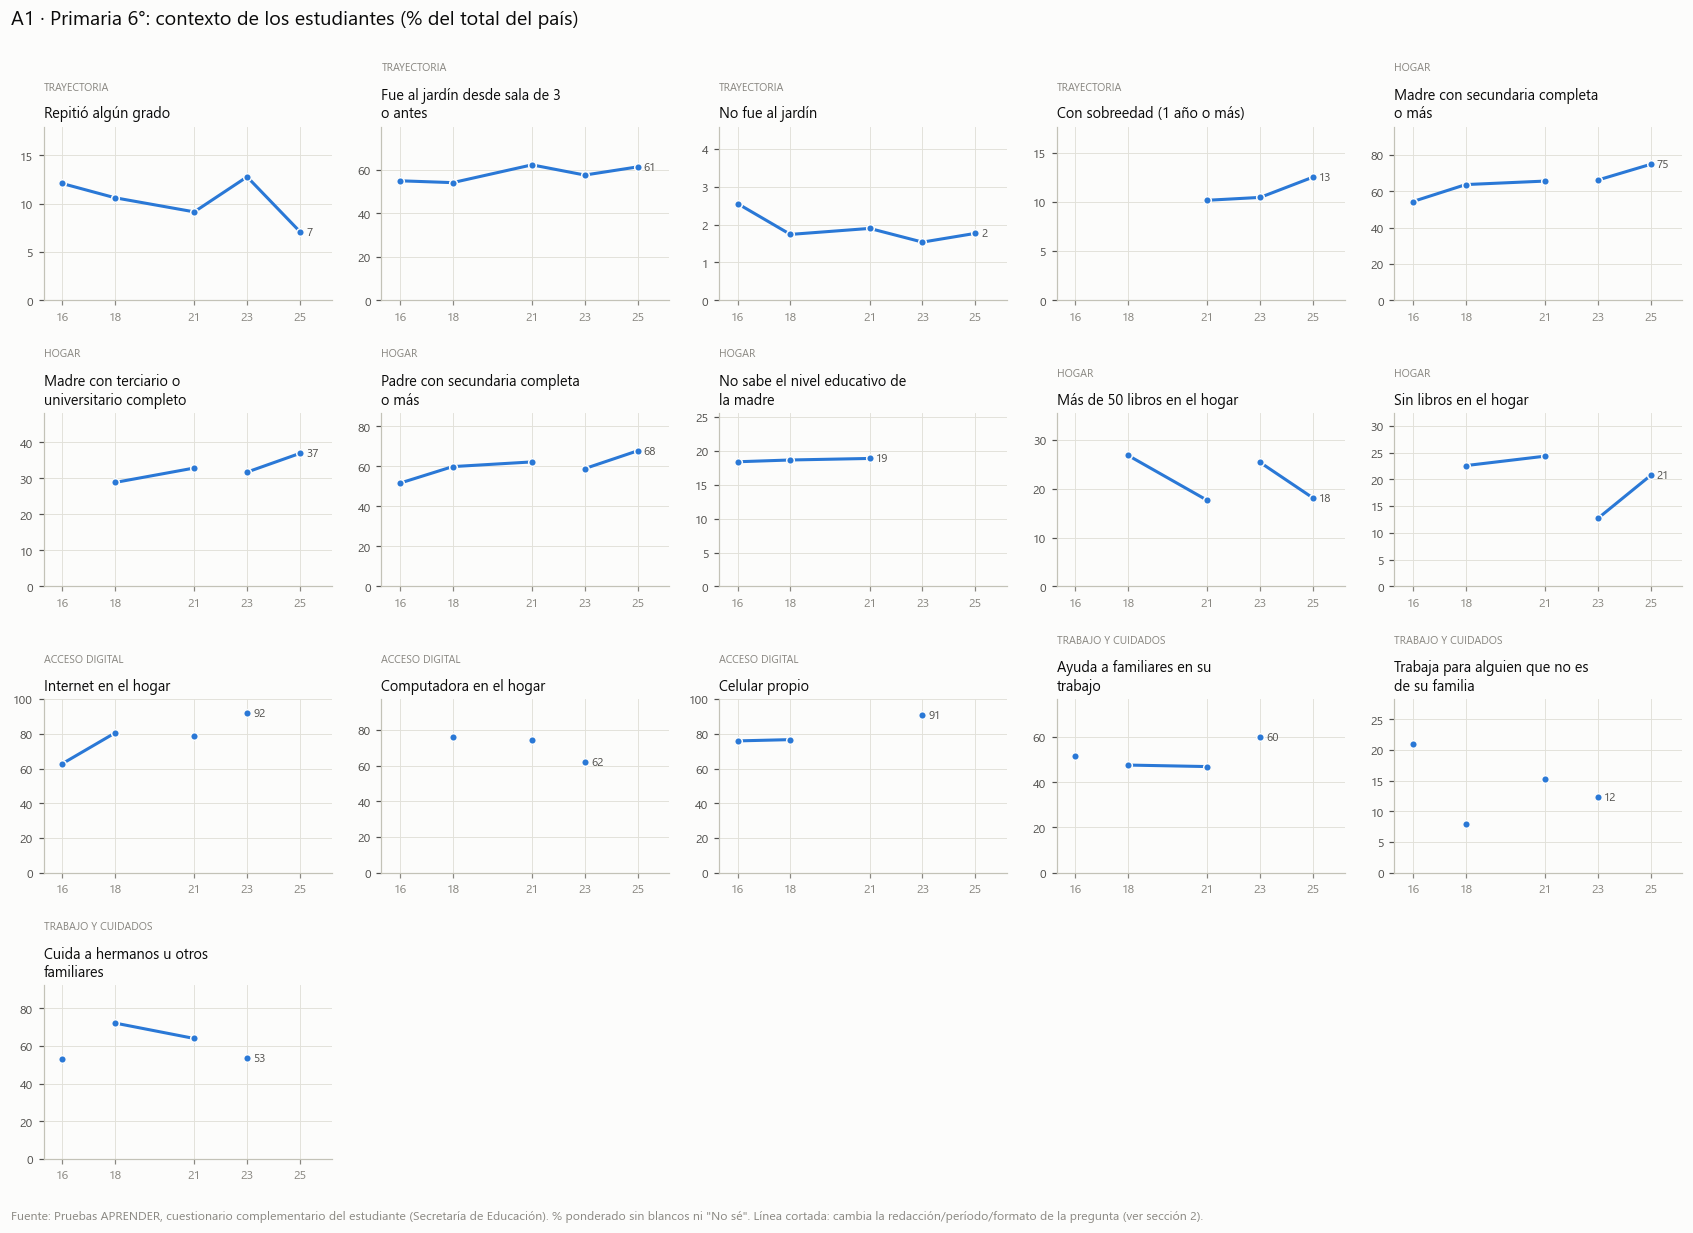

anio                                                             2016  2018  \
tema               indicador                                                  
Trayectoria        Repitió algún grado                           12.1  10.6   
                   Fue al jardín desde sala de 3 o antes         55.0  54.1   
                   No fue al jardín                               2.6   1.7   
                   Con sobreedad (1 año o más)                    NaN   NaN   
Hogar              Madre con secundaria completa o más           54.3  63.7   
                   Madre con terciario o universitario completo   NaN  28.9   
                   Padre con secundaria completa o más           51.6  59.8   
                   No sabe el nivel educativo de la madre        18.4  18.6   
                   Más de 50 libros en el hogar                   NaN  26.8   
                   Sin libros en el hogar                         NaN  22.6   
Acceso digital     Internet en el hogar                          62.7  80.5   
                   Computadora en el hogar                        NaN  76.2   
                   Celular propio                                75.9  76.7   
Trabajo y cuidados Ayuda a familiares en su trabajo              51.6  47.6   
                   Trabaja para alguien que no es de su familia  21.1   7.9   
                   Cuida a hermanos u otros familiares           53.1  72.1   

anio                                                             2021  2023  \
tema               indicador                                                  
Trayectoria        Repitió algún grado                            9.2  12.8   
                   Fue al jardín desde sala de 3 o antes         62.3  57.6   
                   No fue al jardín                               1.9   1.5   
                   Con sobreedad (1 año o más)                   10.2  10.5   
Hogar              Madre con secundaria completa o más           65.6  66.2   
                   Madre con terciario o universitario completo  32.9  31.8   
                   Padre con secundaria completa o más           62.2  58.8   
                   No sabe el nivel educativo de la madre        18.9   NaN   
                   Más de 50 libros en el hogar                  17.6  25.4   
                   Sin libros en el hogar                        24.3  12.7   
Acceso digital     Internet en el hogar                          78.8  91.9   
                   Computadora en el hogar                       74.1  61.8   
                   Celular propio                                 NaN  90.9   
Trabajo y cuidados Ayuda a familiares en su trabajo              46.9  59.8   
                   Trabaja para alguien que no es de su familia  15.3  12.4   
                   Cuida a hermanos u otros familiares           63.9  53.4   

anio                                                             2025  
tema               indicador                                           
Trayectoria        Repitió algún grado                            7.1  
                   Fue al jardín desde sala de 3 o antes         61.4  
                   No fue al jardín                               1.8  
                   Con sobreedad (1 año o más)                   12.5  
Hogar              Madre con secundaria completa o más           74.8  
                   Madre con terciario o universitario completo  36.9  
                   Padre con secundaria completa o más           67.7  
                   No sabe el nivel educativo de la madre         NaN  
                   Más de 50 libros en el hogar                  18.1  
                   Sin libros en el hogar                        20.7  
Acceso digital     Internet en el hogar                           NaN  
                   Computadora en el hogar                        NaN  
                   Celular propio                                 NaN  
Trabajo y cuidados Ayuda a familiares en su trabajo               NaN  
  

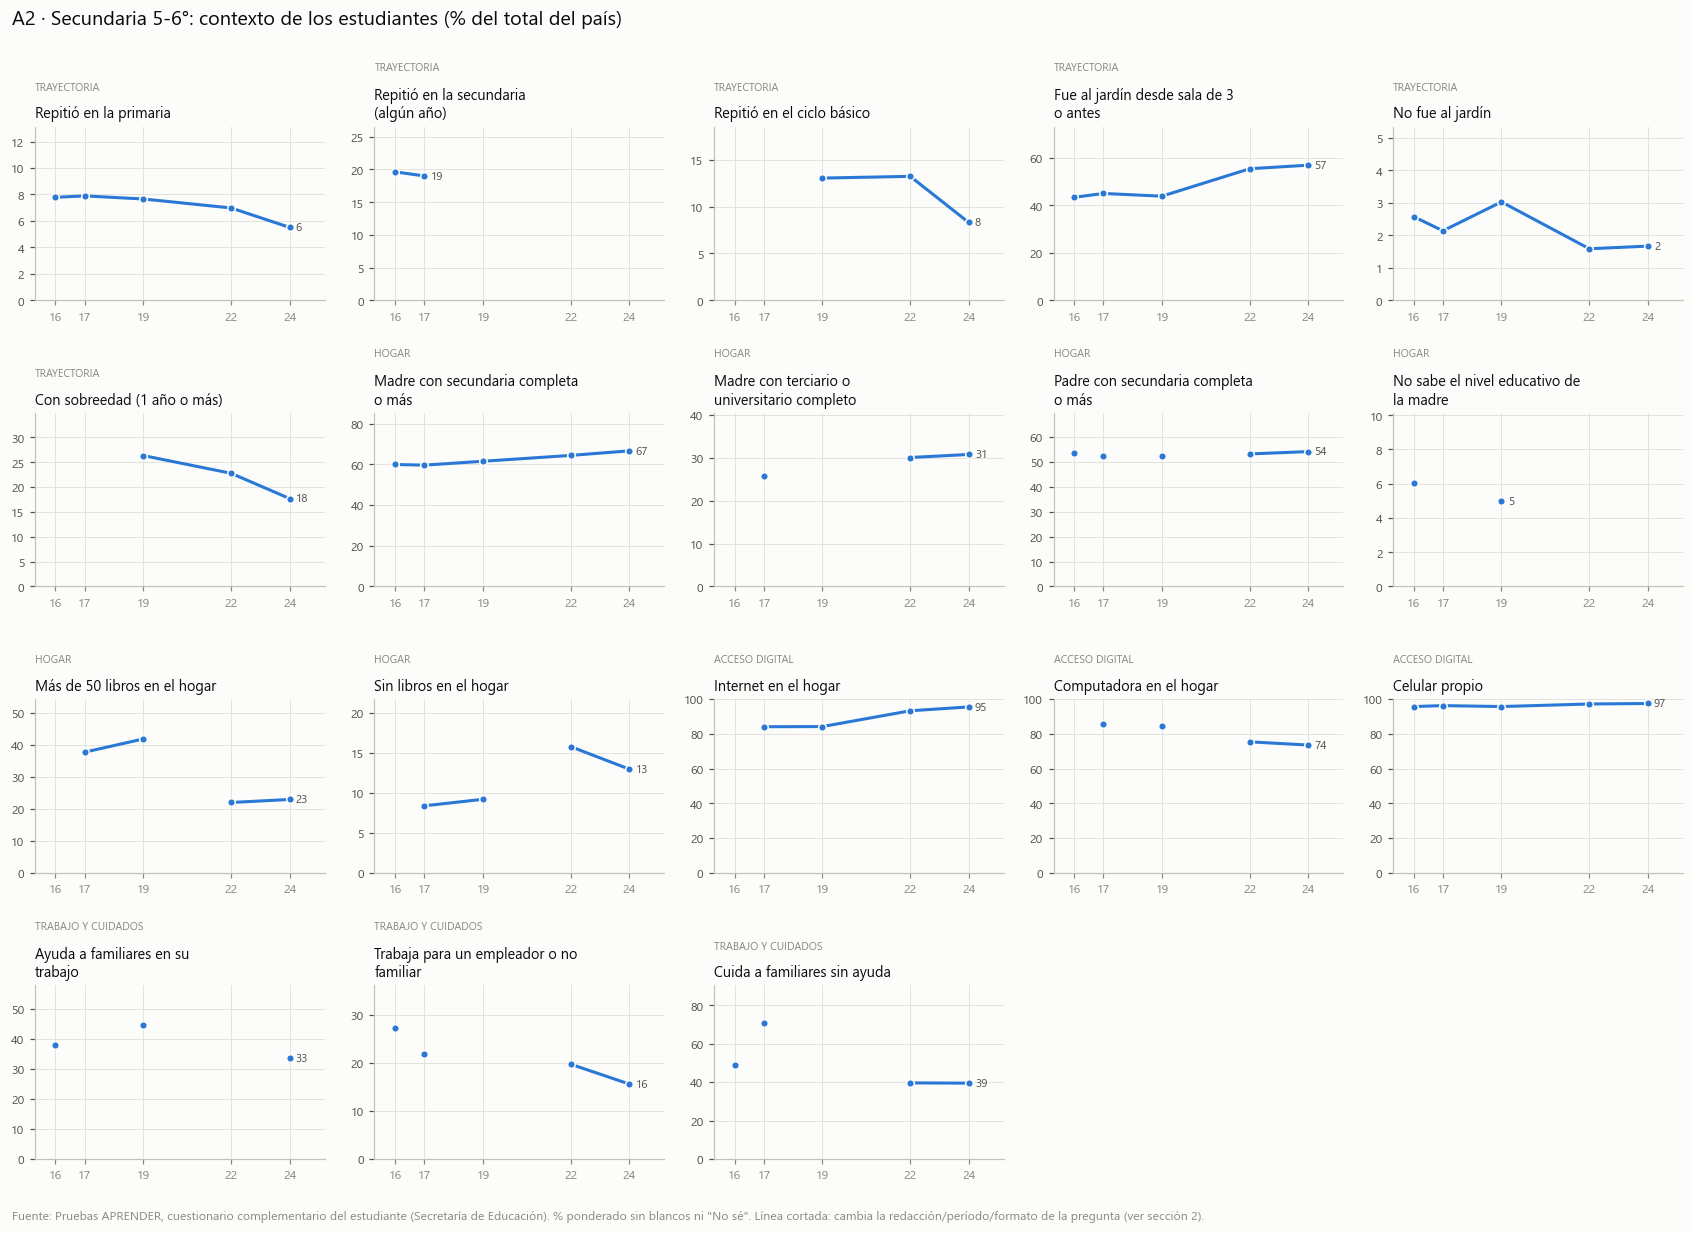

anio                                                             2016  2017  \
tema               indicador                                                  
Trayectoria        Repitió en la primaria                         7.8   7.9   
                   Repitió en la secundaria (algún año)          19.6  19.0   
                   Repitió en el ciclo básico                     NaN   NaN   
                   Fue al jardín desde sala de 3 o antes         43.4  45.1   
                   No fue al jardín                               2.6   2.1   
                   Con sobreedad (1 año o más)                    NaN   NaN   
Hogar              Madre con secundaria completa o más           59.9  59.6   
                   Madre con terciario o universitario completo   NaN  25.8   
                   Padre con secundaria completa o más           53.3  52.2   
                   No sabe el nivel educativo de la madre         6.0   NaN   
                   Más de 50 libros en el hogar                   NaN  37.7   
                   Sin libros en el hogar                         NaN   8.4   
Acceso digital     Internet en el hogar                           NaN  84.1   
                   Computadora en el hogar                        NaN  85.7   
                   Celular propio                                95.7  96.2   
Trabajo y cuidados Ayuda a familiares en su trabajo              38.0   NaN   
                   Trabaja para un empleador o no familiar       27.3  21.7   
                   Cuida a familiares sin ayuda                  48.9  70.7   

anio                                                             2019  2022  \
tema               indicador                                                  
Trayectoria        Repitió en la primaria                         7.7   7.0   
                   Repitió en la secundaria (algún año)           NaN   NaN   
                   Repitió en el ciclo básico                    13.1  13.2   
                   Fue al jardín desde sala de 3 o antes         43.9  55.5   
                   No fue al jardín                               3.0   1.6   
                   Con sobreedad (1 año o más)                   26.3  22.8   
Hogar              Madre con secundaria completa o más           61.5  64.4   
                   Madre con terciario o universitario completo   NaN  30.0   
                   Padre con secundaria completa o más           52.1  53.1   
                   No sabe el nivel educativo de la madre         5.0   NaN   
                   Más de 50 libros en el hogar                  41.8  21.9   
                   Sin libros en el hogar                         9.2  15.8   
Acceso digital     Internet en el hogar                          84.2  93.3   
                   Computadora en el hogar                       84.2  75.4   
                   Celular propio                                95.7  97.2   
Trabajo y cuidados Ayuda a familiares en su trabajo              44.6   NaN   
                   Trabaja para un empleador o no familiar        NaN  19.7   
                   Cuida a familiares sin ayuda                   NaN  39.6   

anio                                                             2024  
tema               indicador                                           
Trayectoria        Repitió en la primaria                         5.5  
                   Repitió en la secundaria (algún año)           NaN  
                   Repitió en el ciclo básico                     8.3  
                   Fue al jardín desde sala de 3 o antes         57.0  
                   No fue al jardín                               1.7  
                   Con sobreedad (1 año o más)                   17.7  
Hogar              Madre con secundaria completa o más           66.6  
                   Madre con terciario o universitario completo  30.8  
                   Padre con secundaria completa o más           54.0  
                   No sabe el nivel educativo 

In [5]:
def tramos(anios, tags):
    """Años consecutivos (de la cohorte) con la misma etiqueta de redacción; None corta el tramo."""
    out, cur, prev = [], [], object()
    for a, t in zip(anios, tags):
        if t is None or (cur and t != prev):
            if cur: out.append(cur)
            cur = []
        if t is not None: cur.append(a)
        prev = t
    if cur: out.append(cur)
    return out

def panel(ax, t, anios, grupos, colores, rotular):
    """Dibuja un indicador: una serie por grupo, cortada donde cambia la redacción."""
    for g, col in zip(grupos, colores):
        s = (t if g is None else t[t.grupo == g]).set_index('anio').reindex(anios)
        tags = [None if pd.isna(v) else v for v in s.redaccion]
        for tr in tramos(anios, tags):
            ax.plot(tr, s.loc[tr, 'pct'], color=col, lw=2, marker='o', ms=5, mec=SUPERFICIE, mew=1)
        if rotular and s.pct.notna().any():
            a = s.pct.last_valid_index()
            ax.annotate(f'{s.pct[a]:.0f}', (a, s.pct[a]), xytext=(4, 0), textcoords='offset points', fontsize=7.5,
                        color=TINTA_2, va='center')
    ax.set_xticks(anios); ax.set_xticklabels([str(a)[2:] for a in anios], fontsize=8)
    ax.set_xlim(anios[0] - 0.7, anios[-1] + 1.2)
    ax.tick_params(axis='y', labelsize=8)

def multiples(tabla_larga, coh, grupos=(None,), colores=(AZUL,), titulo='', leyenda=None, rotular=True):
    lista = IND[coh]; anios = COHORTES[coh]['anios']
    n = len(lista); nc = 5; nf = int(np.ceil(n / nc))
    fig, axs = plt.subplots(nf, nc, figsize=(15.5, 2.55 * nf + 0.6), squeeze=False)
    for i, (tema, nombre, _) in enumerate(lista):
        ax = axs.flat[i]
        t = tabla_larga[(tabla_larga.cohorte == coh) & (tabla_larga.indicador == nombre)]
        panel(ax, t, anios, grupos, colores, rotular)
        top = t.pct.max()
        ax.set_ylim(0, min(100, top * 1.25 + 2) if top > 8 else top * 1.6 + 0.5)
        tit = textwrap.fill(nombre, 30)
        ax.set_title(tit, fontsize=9.5, loc='left')
        ax.annotate(tema.upper(), xy=(0, 1), xycoords='axes fraction', xytext=(0, 9 + 13 * (tit.count('\n') + 1)),
                    textcoords='offset points', fontsize=7, color=TENUE, va='bottom')
    for ax in axs.flat[n:]: ax.set_visible(False)
    fig.suptitle(titulo, x=0.01, ha='left', fontsize=13, y=1.0)
    if leyenda:
        fig.legend(handles=[Line2D([], [], color=c, lw=2, marker='o', label=l) for l, c in zip(leyenda, colores)],
                   loc='upper right', ncol=len(leyenda), frameon=False, bbox_to_anchor=(0.99, 1.01))
    fig.tight_layout(h_pad=1.6)
    nota(fig, FUENTE_AP + ' Línea cortada: cambia la redacción/período/formato de la pregunta (ver sección 2).')
    return fig

def ancho(t, por=None):
    idx = ['tema', 'indicador'] + ([por] if por else [])
    w = t.pivot_table(index=['orden'] + idx, columns='anio', values='pct').round(1)
    return w.droplevel('orden')

for i, coh in enumerate(COHORTES, start=1):
    guardar(multiples(PAIS, coh, titulo=f'A{i} · {coh}: contexto de los estudiantes (% del total del país)'), f'A{i}_pais_{"primaria" if i == 1 else "secundaria"}')
    plt.show()
    display(ancho(PAIS[PAIS.cohorte == coh]))

---
## B · Por sector de gestión y ámbito
Mismos indicadores para **estatal vs privado** (B1, B2) y **urbano vs rural** (B3, B4). La tabla muestra la **brecha en
puntos porcentuales** (privado − estatal; urbano − rural) por año.

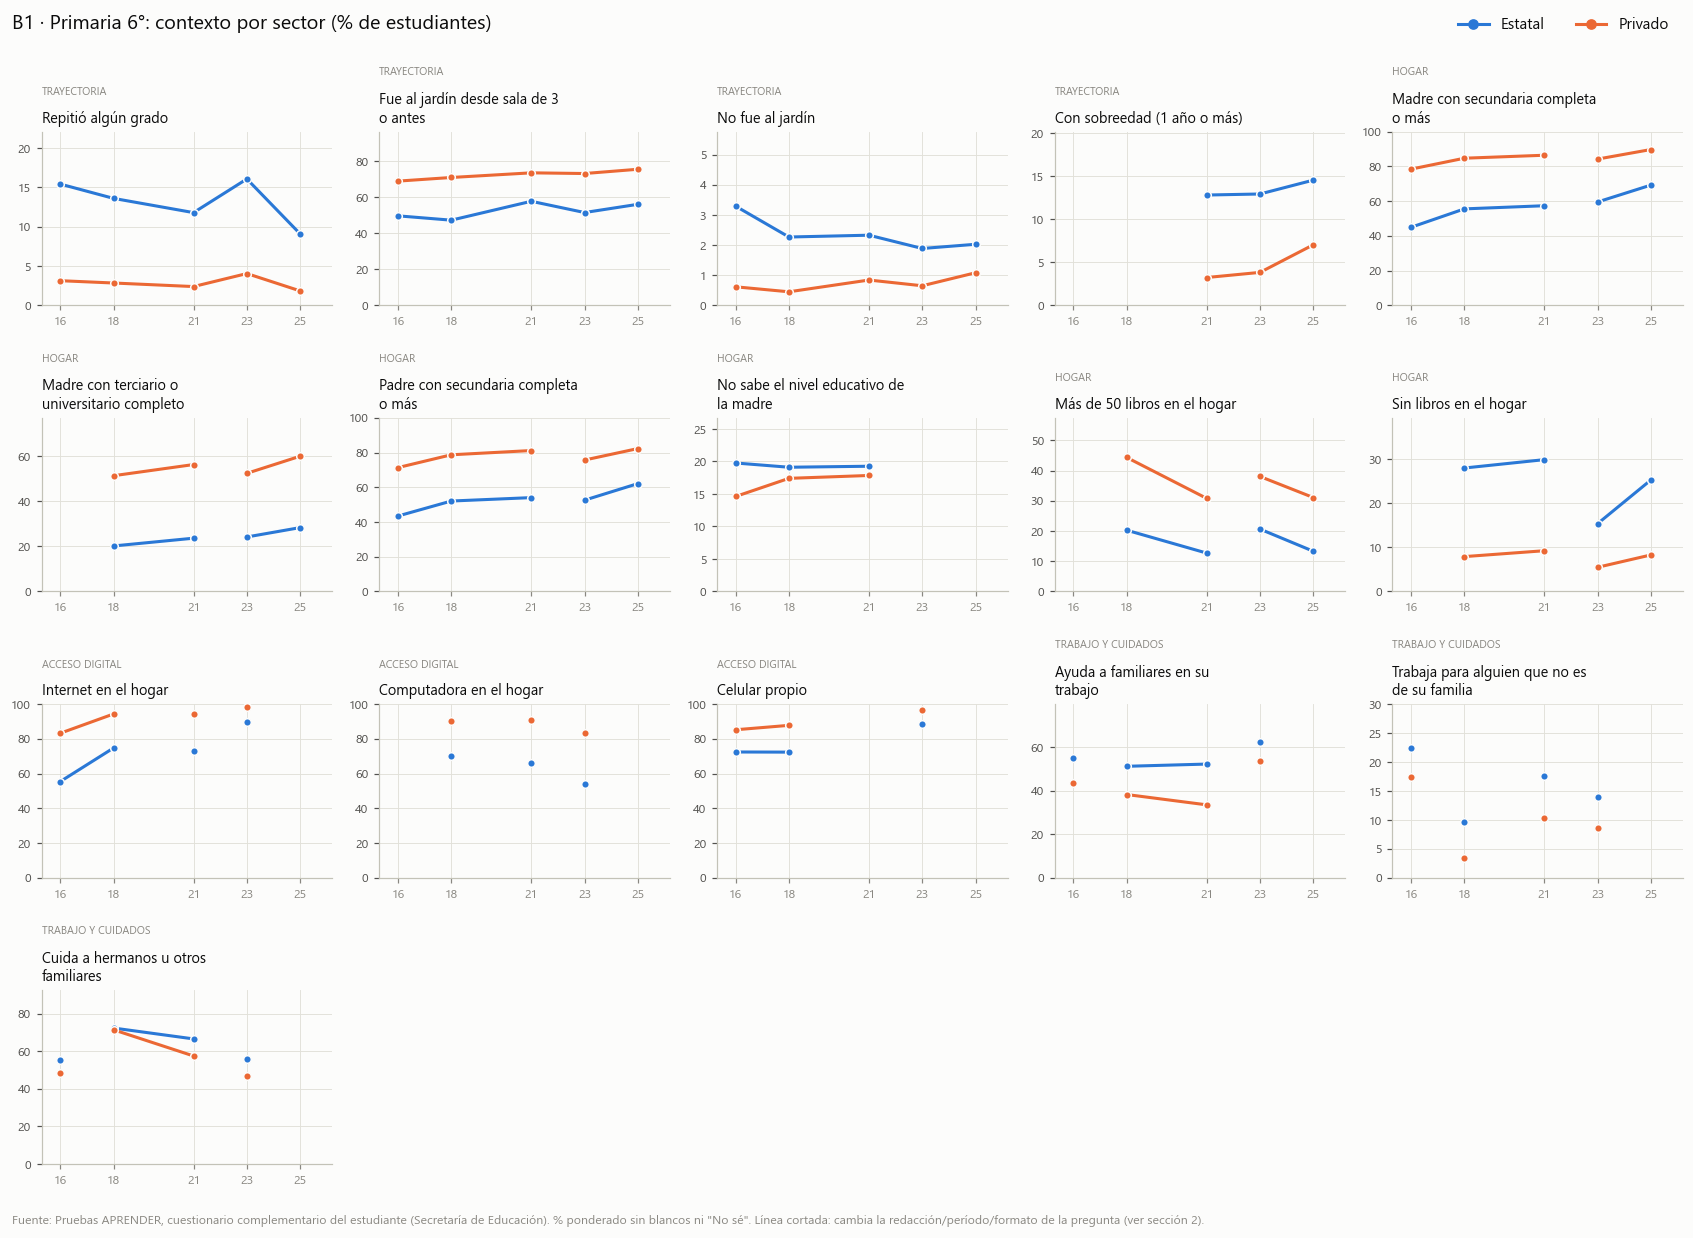

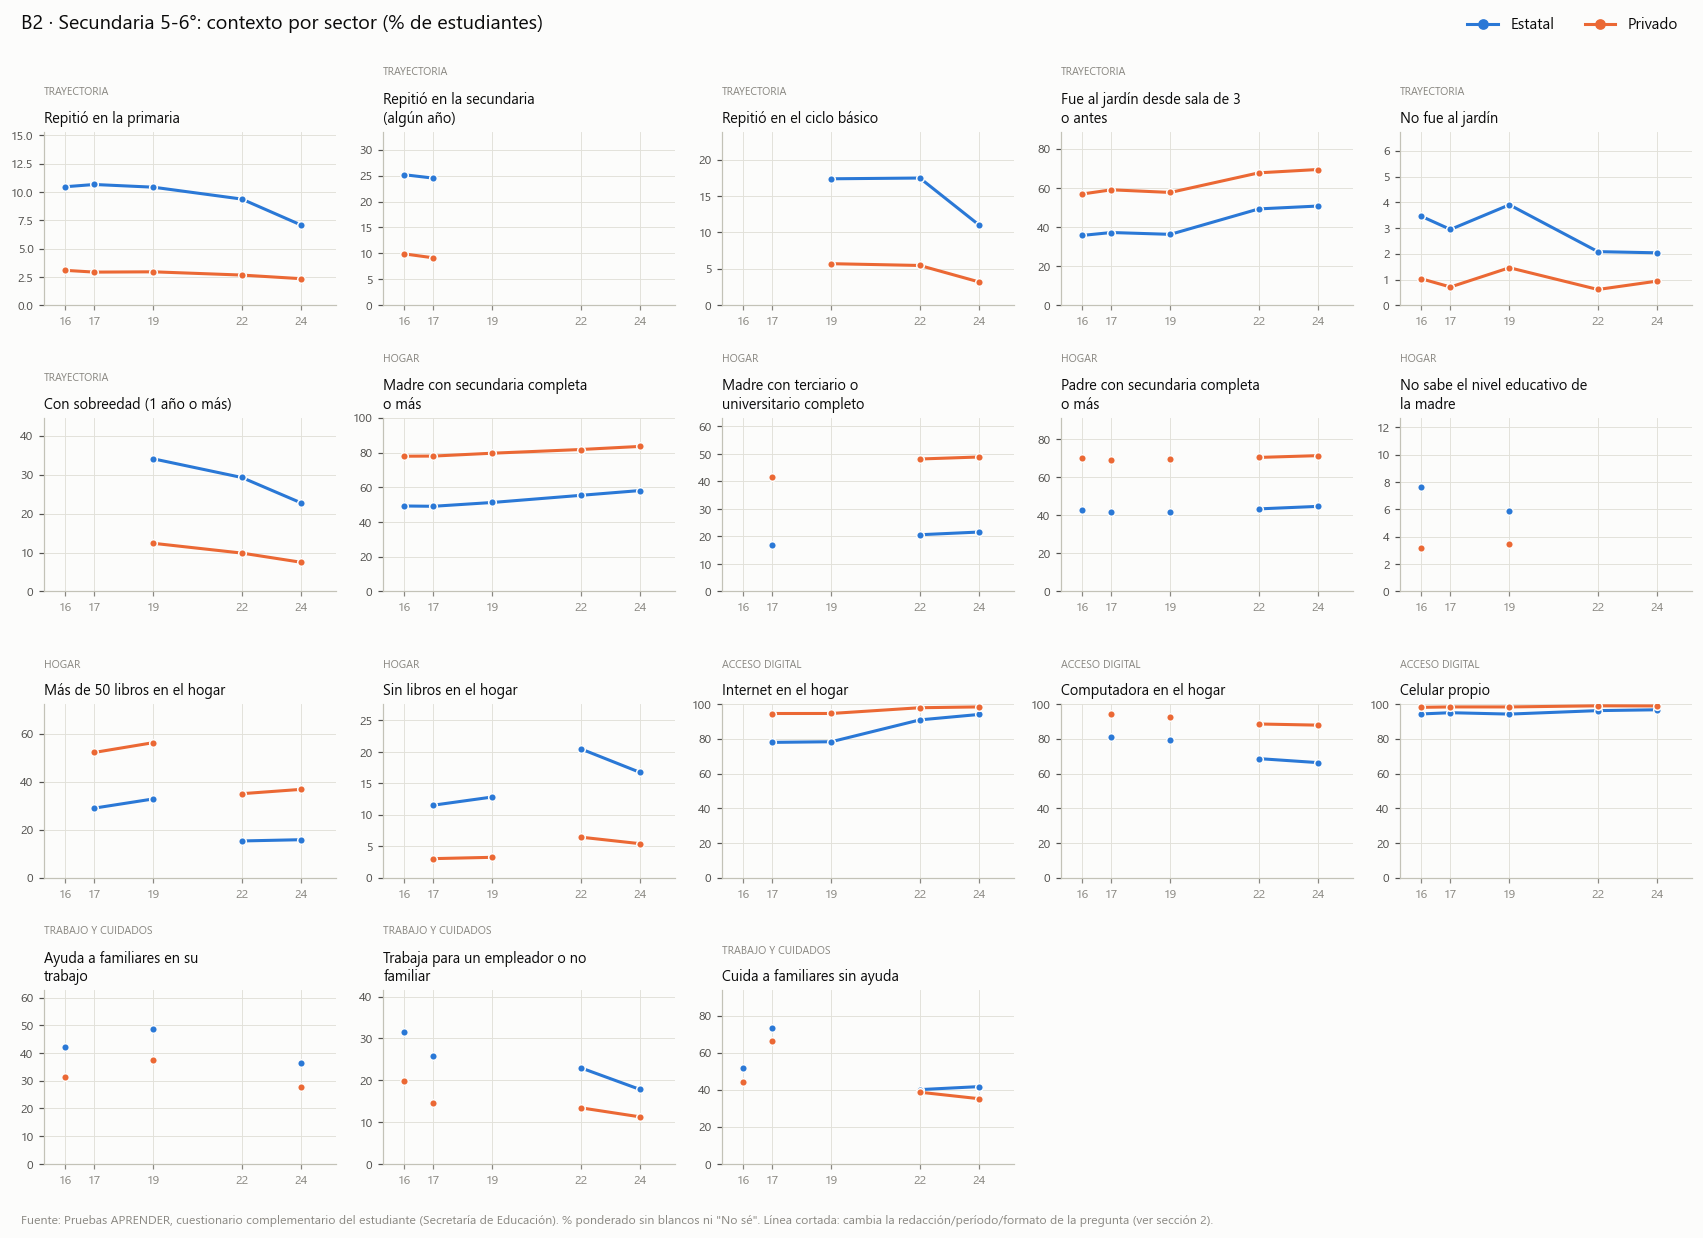


Brecha Privado − Estatal (pp) · Primaria 6°


anio                                                             2016  2018  \
tema               indicador                                                  
Trayectoria        Repitió algún grado                          -12.3 -10.8   
                   Fue al jardín desde sala de 3 o antes         19.3  23.7   
                   No fue al jardín                              -2.7  -1.8   
                   Con sobreedad (1 año o más)                    NaN   NaN   
Hogar              Madre con secundaria completa o más           33.5  29.2   
                   Madre con terciario o universitario completo   NaN  31.1   
                   Padre con secundaria completa o más           27.9  26.6   
                   No sabe el nivel educativo de la madre        -5.2  -1.7   
                   Más de 50 libros en el hogar                   NaN  24.1   
                   Sin libros en el hogar                         NaN -20.1   
Acceso digital     Internet en el hogar                          27.8  19.6   
                   Computadora en el hogar                        NaN  20.5   
                   Celular propio                                12.8  15.4   
Trabajo y cuidados Ayuda a familiares en su trabajo             -11.6 -13.0   
                   Trabaja para alguien que no es de su familia  -5.0  -6.1   
                   Cuida a hermanos u otros familiares           -6.9  -0.9   

anio                                                             2021  2023  \
tema               indicador                                                  
Trayectoria        Repitió algún grado                           -9.4 -12.0   
                   Fue al jardín desde sala de 3 o antes         15.8  21.7   
                   No fue al jardín                              -1.5  -1.2   
                   Con sobreedad (1 año o más)                   -9.6  -9.1   
Hogar              Madre con secundaria completa o más           29.1  24.7   
                   Madre con terciario o universitario completo  32.6  28.2   
                   Padre con secundaria completa o más           27.1  23.1   
                   No sabe el nivel educativo de la madre        -1.4   NaN   
                   Más de 50 libros en el hogar                  18.1  17.4   
                   Sin libros en el hogar                       -20.7  -9.9   
Acceso digital     Internet en el hogar                          21.6   9.0   
                   Computadora en el hogar                       24.9  29.3   
                   Celular propio                                 NaN   8.0   
Trabajo y cuidados Ayuda a familiares en su trabajo             -18.7  -8.7   
                   Trabaja para alguien que no es de su familia  -7.2  -5.4   
                   Cuida a hermanos u otros familiares           -9.1  -9.5   

anio                                                             2025  
tema               indicador                                           
Trayectoria        Repitió algún grado                           -7.2  
                   Fue al jardín desde sala de 3 o antes         19.5  
                   No fue al jardín                              -0.9  
                   Con sobreedad (1 año o más)                   -7.5  
Hogar              Madre con secundaria completa o más           20.5  
                   Madre con terciario o universitario completo  31.6  
                   Padre con secundaria completa o más           20.2  
                   No sabe el nivel educativo de la madre         NaN  
                   Más de 50 libros en el hogar                  17.8  
                   Sin libros en el hogar                       -17.0  
Acceso digital     Internet en el hogar                           NaN  
                   Computadora en el hogar                        NaN  
                   Celular propio                                 NaN  
Trabajo y cuidados Ayuda a familiares en su trabajo               NaN  
  


Brecha Privado − Estatal (pp) · Secundaria 5-6°


anio                                                             2016  2017  \
tema               indicador                                                  
Trayectoria        Repitió en la primaria                        -7.4  -7.7   
                   Repitió en la secundaria (algún año)         -15.3 -15.4   
                   Repitió en el ciclo básico                     NaN   NaN   
                   Fue al jardín desde sala de 3 o antes         21.2  21.8   
                   No fue al jardín                              -2.4  -2.2   
                   Con sobreedad (1 año o más)                    NaN   NaN   
Hogar              Madre con secundaria completa o más           28.7  28.9   
                   Madre con terciario o universitario completo   NaN  24.8   
                   Padre con secundaria completa o más           27.2  27.5   
                   No sabe el nivel educativo de la madre        -4.4   NaN   
                   Más de 50 libros en el hogar                   NaN  23.2   
                   Sin libros en el hogar                         NaN  -8.5   
Acceso digital     Internet en el hogar                           NaN  16.6   
                   Computadora en el hogar                        NaN  13.2   
                   Celular propio                                 3.8   3.3   
Trabajo y cuidados Ayuda a familiares en su trabajo             -10.6   NaN   
                   Trabaja para un empleador o no familiar      -11.9 -11.1   
                   Cuida a familiares sin ayuda                  -7.4  -6.9   

anio                                                             2019  2022  \
tema               indicador                                                  
Trayectoria        Repitió en la primaria                        -7.5  -6.7   
                   Repitió en la secundaria (algún año)           NaN   NaN   
                   Repitió en el ciclo básico                   -11.7 -12.0   
                   Fue al jardín desde sala de 3 o antes         21.4  18.4   
                   No fue al jardín                              -2.4  -1.5   
                   Con sobreedad (1 año o más)                  -21.7 -19.4   
Hogar              Madre con secundaria completa o más           28.4  26.4   
                   Madre con terciario o universitario completo   NaN  27.5   
                   Padre con secundaria completa o más           27.8  27.0   
                   No sabe el nivel educativo de la madre        -2.4   NaN   
                   Más de 50 libros en el hogar                  23.5  19.7   
                   Sin libros en el hogar                        -9.6 -14.0   
Acceso digital     Internet en el hogar                          16.3   7.0   
                   Computadora en el hogar                       13.1  19.9   
                   Celular propio                                 4.1   2.8   
Trabajo y cuidados Ayuda a familiares en su trabajo             -10.8   NaN   
                   Trabaja para un empleador o no familiar        NaN  -9.6   
                   Cuida a familiares sin ayuda                   NaN  -1.4   

anio                                                             2024  
tema               indicador                                           
Trayectoria        Repitió en la primaria                        -4.8  
                   Repitió en la secundaria (algún año)           NaN  
                   Repitió en el ciclo básico                    -7.8  
                   Fue al jardín desde sala de 3 o antes         18.7  
                   No fue al jardín                              -1.1  
                   Con sobreedad (1 año o más)                  -15.3  
Hogar              Madre con secundaria completa o más           25.4  
                   Madre con terciario o universitario completo  27.3  
                   Padre con secundaria completa o más           26.7  
                   No sabe el nivel educativo 

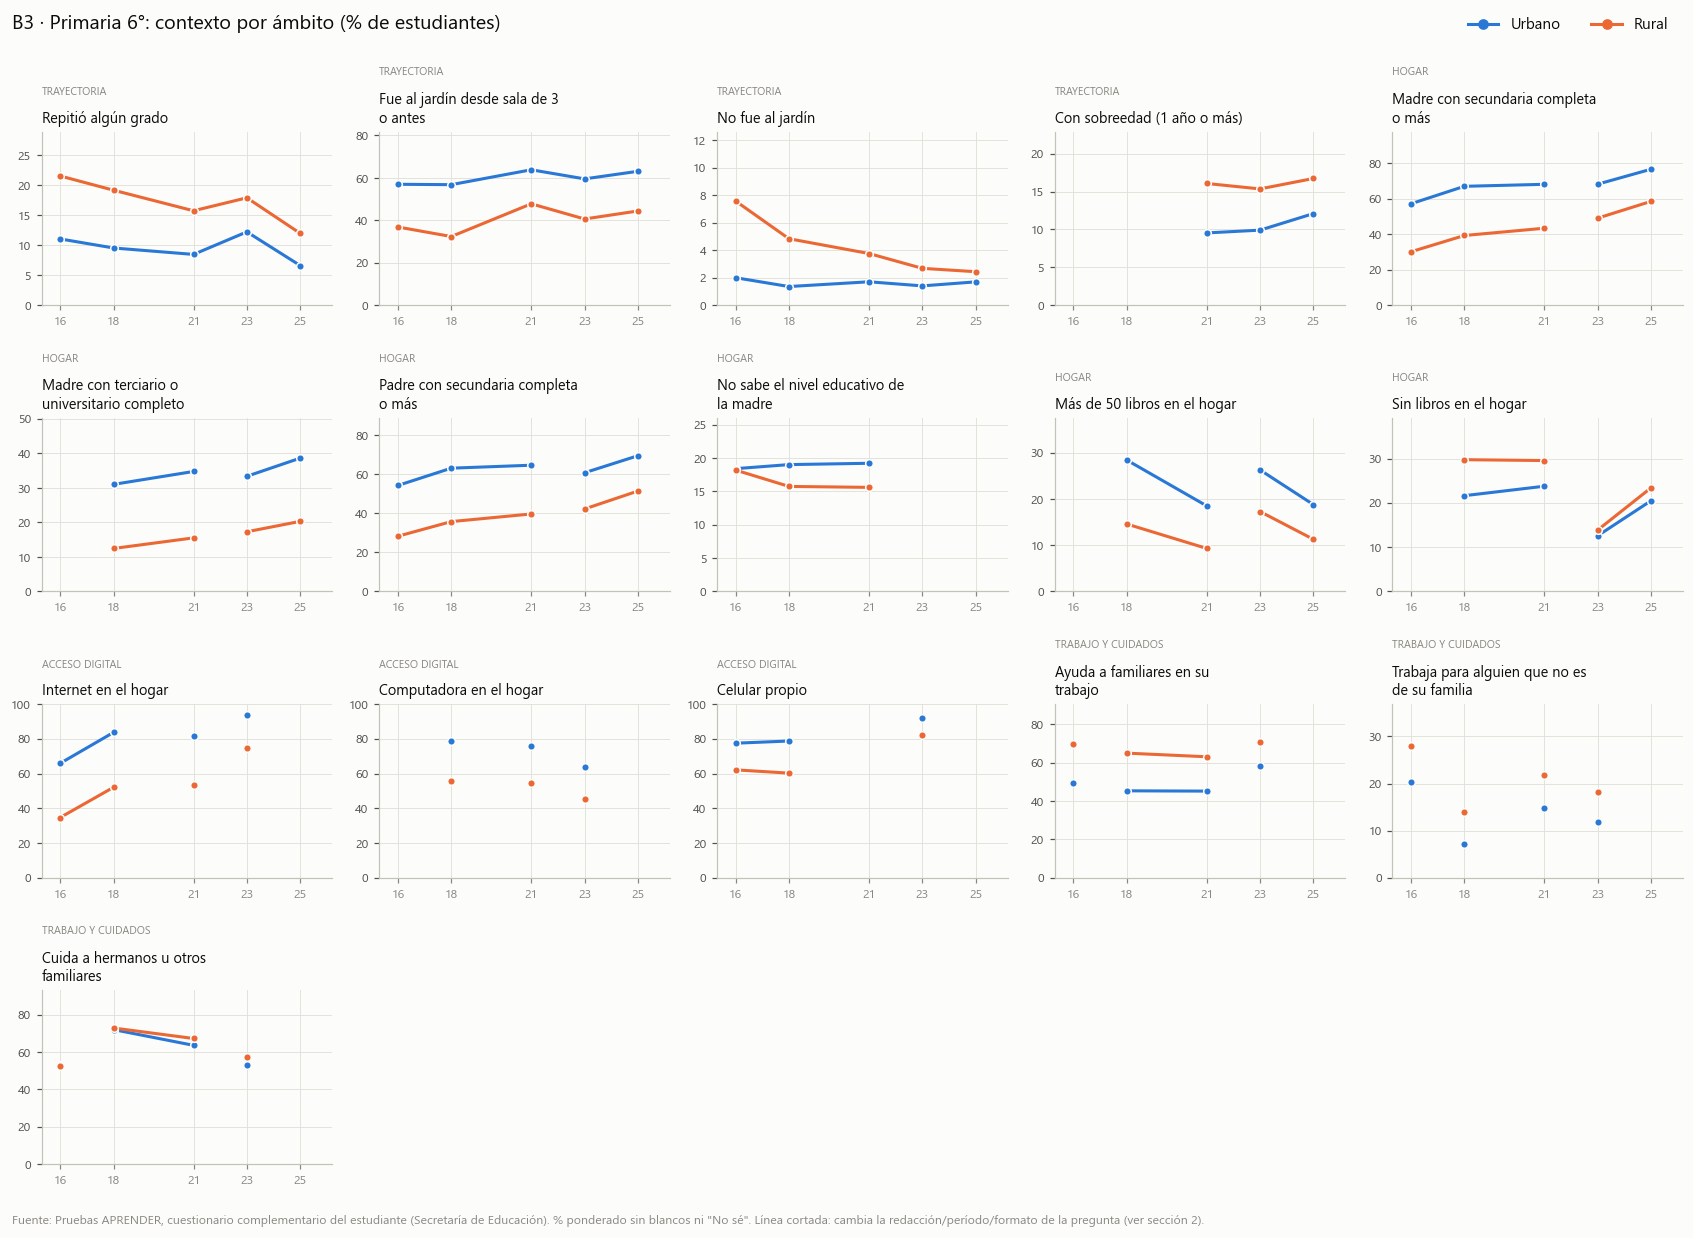

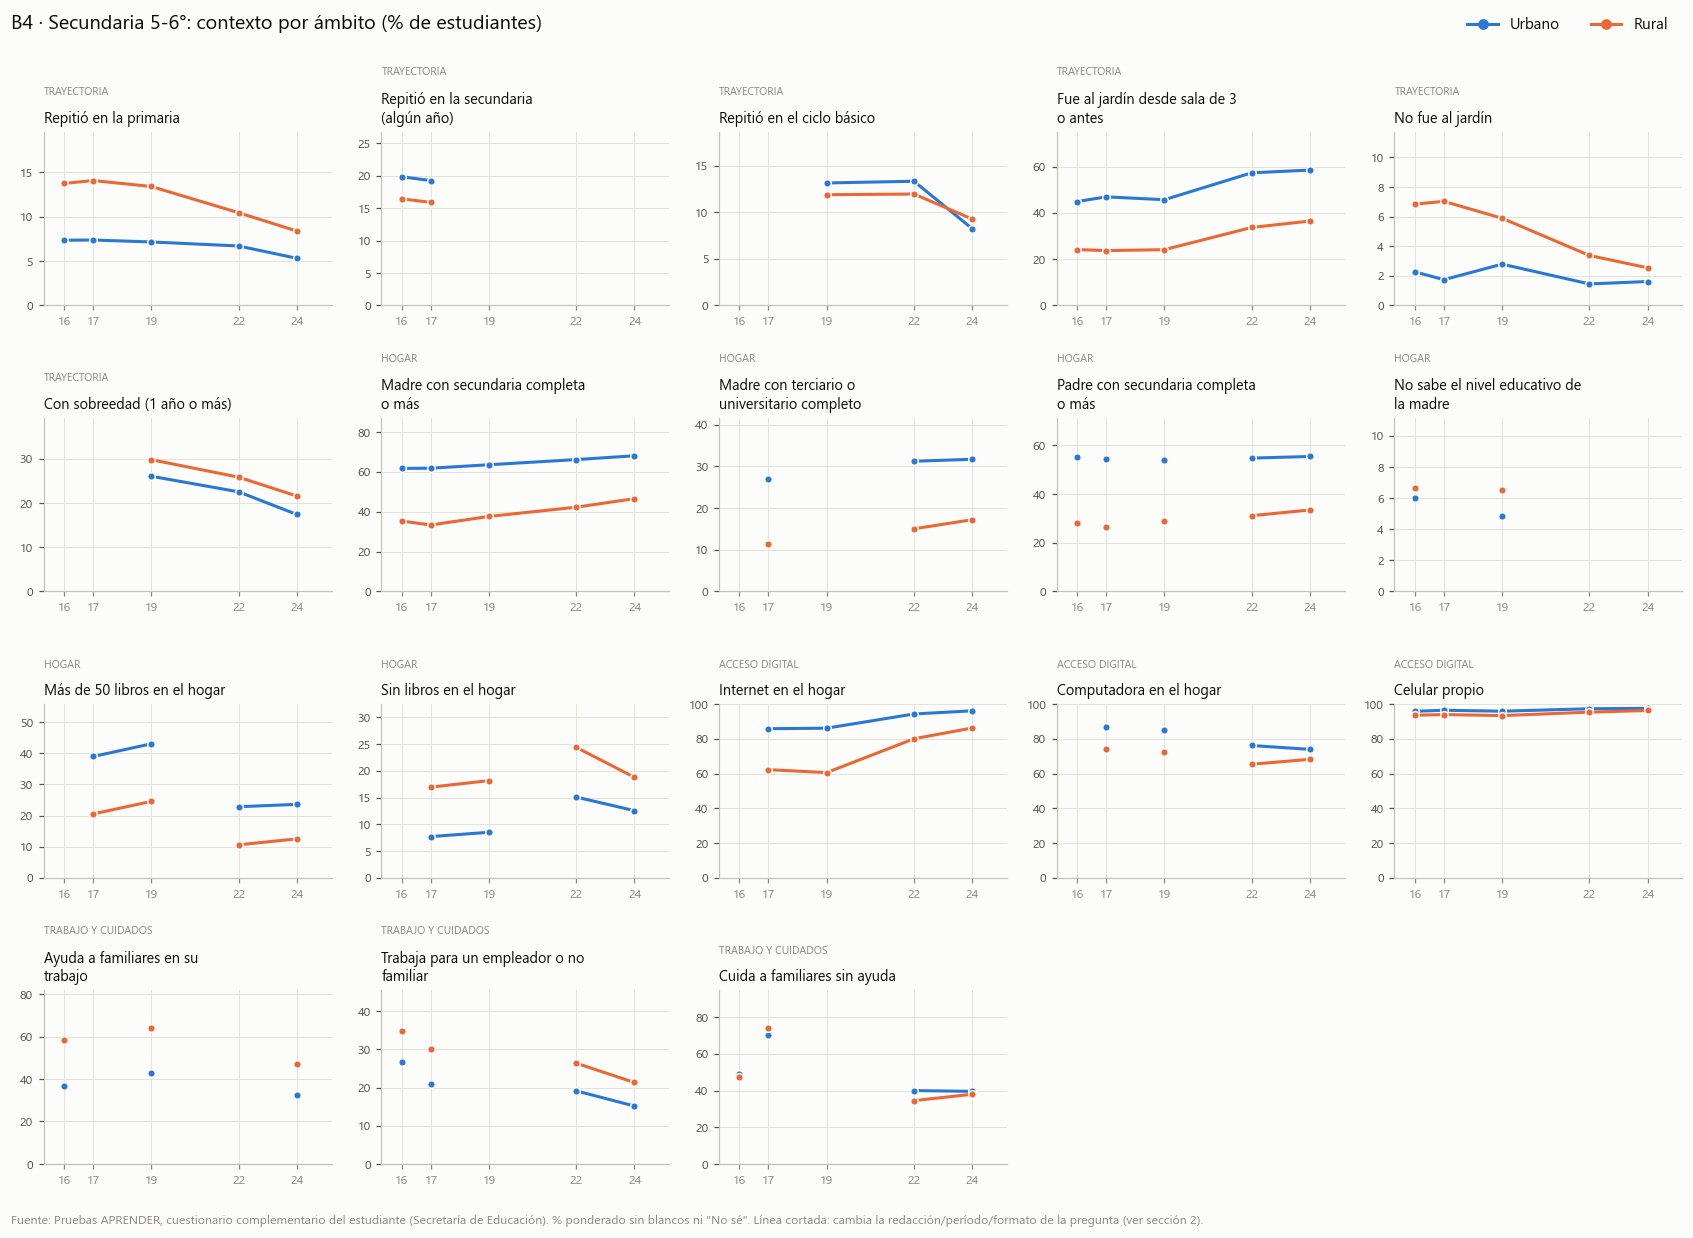


Brecha Urbano − Rural (pp) · Primaria 6°


anio                                                             2016  2018  \
tema               indicador                                                  
Trayectoria        Repitió algún grado                          -10.5  -9.6   
                   Fue al jardín desde sala de 3 o antes         20.1  24.4   
                   No fue al jardín                              -5.6  -3.5   
                   Con sobreedad (1 año o más)                    NaN   NaN   
Hogar              Madre con secundaria completa o más           27.0  27.7   
                   Madre con terciario o universitario completo   NaN  18.6   
                   Padre con secundaria completa o más           26.0  27.3   
                   No sabe el nivel educativo de la madre         0.2   3.3   
                   Más de 50 libros en el hogar                   NaN  13.8   
                   Sin libros en el hogar                         NaN  -8.1   
Acceso digital     Internet en el hogar                          31.2  31.6   
                   Computadora en el hogar                        NaN  22.6   
                   Celular propio                                15.4  18.5   
Trabajo y cuidados Ayuda a familiares en su trabajo             -20.1 -19.7   
                   Trabaja para alguien que no es de su familia  -7.6  -6.9   
                   Cuida a hermanos u otros familiares            0.5  -0.9   

anio                                                             2021  2023  \
tema               indicador                                                  
Trayectoria        Repitió algún grado                           -7.3  -5.7   
                   Fue al jardín desde sala de 3 o antes         16.0  18.9   
                   No fue al jardín                              -2.1  -1.3   
                   Con sobreedad (1 año o más)                   -6.5  -5.4   
Hogar              Madre con secundaria completa o más           24.7  19.1   
                   Madre con terciario o universitario completo  19.2  16.1   
                   Padre con secundaria completa o más           24.9  18.5   
                   No sabe el nivel educativo de la madre         3.6   NaN   
                   Más de 50 libros en el hogar                   9.2   9.0   
                   Sin libros en el hogar                        -5.8  -1.3   
Acceso digital     Internet en el hogar                          28.4  18.9   
                   Computadora en el hogar                       21.4  18.0   
                   Celular propio                                 NaN   9.4   
Trabajo y cuidados Ayuda a familiares en su trabajo             -17.9 -12.4   
                   Trabaja para alguien que no es de su familia  -7.1  -6.4   
                   Cuida a hermanos u otros familiares           -3.7  -4.3   

anio                                                             2025  
tema               indicador                                           
Trayectoria        Repitió algún grado                           -5.4  
                   Fue al jardín desde sala de 3 o antes         18.7  
                   No fue al jardín                              -0.7  
                   Con sobreedad (1 año o más)                   -4.6  
Hogar              Madre con secundaria completa o más           18.1  
                   Madre con terciario o universitario completo  18.3  
                   Padre con secundaria completa o más           18.1  
                   No sabe el nivel educativo de la madre         NaN  
                   Más de 50 libros en el hogar                   7.5  
                   Sin libros en el hogar                        -2.9  
Acceso digital     Internet en el hogar                           NaN  
                   Computadora en el hogar                        NaN  
                   Celular propio                                 NaN  
Trabajo y cuidados Ayuda a familiares en su trabajo               NaN  
  


Brecha Urbano − Rural (pp) · Secundaria 5-6°


anio                                                             2016  2017  \
tema               indicador                                                  
Trayectoria        Repitió en la primaria                        -6.4  -6.7   
                   Repitió en la secundaria (algún año)           3.4   3.4   
                   Repitió en el ciclo básico                     NaN   NaN   
                   Fue al jardín desde sala de 3 o antes         20.8  23.2   
                   No fue al jardín                              -4.6  -5.3   
                   Con sobreedad (1 año o más)                    NaN   NaN   
Hogar              Madre con secundaria completa o más           26.4  28.5   
                   Madre con terciario o universitario completo   NaN  15.5   
                   Padre con secundaria completa o más           26.9  27.9   
                   No sabe el nivel educativo de la madre        -0.7   NaN   
                   Más de 50 libros en el hogar                   NaN  18.5   
                   Sin libros en el hogar                         NaN  -9.3   
Acceso digital     Internet en el hogar                           NaN  23.6   
                   Computadora en el hogar                        NaN  12.2   
                   Celular propio                                 2.3   2.5   
Trabajo y cuidados Ayuda a familiares en su trabajo             -21.7   NaN   
                   Trabaja para un empleador o no familiar       -8.1  -9.2   
                   Cuida a familiares sin ayuda                   1.8  -3.7   

anio                                                             2019  2022  \
tema               indicador                                                  
Trayectoria        Repitió en la primaria                        -6.3  -3.8   
                   Repitió en la secundaria (algún año)           NaN   NaN   
                   Repitió en el ciclo básico                     1.3   1.4   
                   Fue al jardín desde sala de 3 o antes         21.6  23.6   
                   No fue al jardín                              -3.1  -1.9   
                   Con sobreedad (1 año o más)                   -3.7  -3.3   
Hogar              Madre con secundaria completa o más           25.9  23.9   
                   Madre con terciario o universitario completo   NaN  16.2   
                   Padre con secundaria completa o más           25.0  23.7   
                   No sabe el nivel educativo de la madre        -1.6   NaN   
                   Más de 50 libros en el hogar                  18.5  12.3   
                   Sin libros en el hogar                        -9.7  -9.3   
Acceso digital     Internet en el hogar                          25.6  14.3   
                   Computadora en el hogar                       13.0  10.8   
                   Celular propio                                 2.5   2.0   
Trabajo y cuidados Ayuda a familiares en su trabajo             -20.9   NaN   
                   Trabaja para un empleador o no familiar        NaN  -7.2   
                   Cuida a familiares sin ayuda                   NaN   5.5   

anio                                                             2024  
tema               indicador                                           
Trayectoria        Repitió en la primaria                        -3.1  
                   Repitió en la secundaria (algún año)           NaN  
                   Repitió en el ciclo básico                    -1.0  
                   Fue al jardín desde sala de 3 o antes         22.0  
                   No fue al jardín                              -0.9  
                   Con sobreedad (1 año o más)                   -4.2  
Hogar              Madre con secundaria completa o más           21.5  
                   Madre con terciario o universitario completo  14.5  
                   Padre con secundaria completa o más           22.0  
                   No sabe el nivel educativo 

In [6]:
def brecha(t, col, a, b):
    w = t.pivot_table(index=['cohorte', 'orden', 'tema', 'indicador', 'anio'], columns=col, values='pct')
    return (w[a] - w[b]).rename(f'{a} − {b} (pp)').reset_index()

BRECHAS = {}
k = 1
for dim, col, grupos, etiq in [('sector', 'sector', ['Estatal', 'Privado'], ['Estatal', 'Privado']),
                               ('ámbito', 'ambito', ['Urbano', 'Rural'], ['Urbano', 'Rural'])]:
    t = (POR_SECTOR if col == 'sector' else POR_AMBITO).rename(columns={col: 'grupo'})
    for coh in COHORTES:
        fig = multiples(t, coh, grupos=grupos, colores=[AZUL, NARANJA], leyenda=etiq, rotular=False,
                        titulo=f'B{k} · {coh}: contexto por {dim} (% de estudiantes)')
        guardar(fig, f'B{k}_{col}_{"primaria" if coh.startswith("Prim") else "secundaria"}'); plt.show()
        k += 1
    a, b = ('Privado', 'Estatal') if col == 'sector' else ('Urbano', 'Rural')
    br = brecha(t.rename(columns={'grupo': col}), col, a, b)
    BRECHAS[col] = br
    for coh in COHORTES:
        print(f'\nBrecha {a} − {b} (pp) · {coh}')
        display(br[br.cohorte == coh].pivot_table(index=['orden', 'tema', 'indicador'], columns='anio', values=f'{a} − {b} (pp)').round(1).droplevel('orden'))

---
## C · Provincias
Para cada indicador se toma el **último tramo comparable** (años consecutivos con la misma redacción, de al menos dos
operativos y que llega a uno de los dos últimos) y se calcula el **cambio en pp** entre su primer y último año, por provincia. Azul = sube,
rojo = baja (sin juicio de valor: que baje la repitencia o el trabajo infantil es una mejora). Escala recortada a ±15 pp;
el número es el valor exacto. Los valores de todos los años están en la hoja `provincias` del Excel.

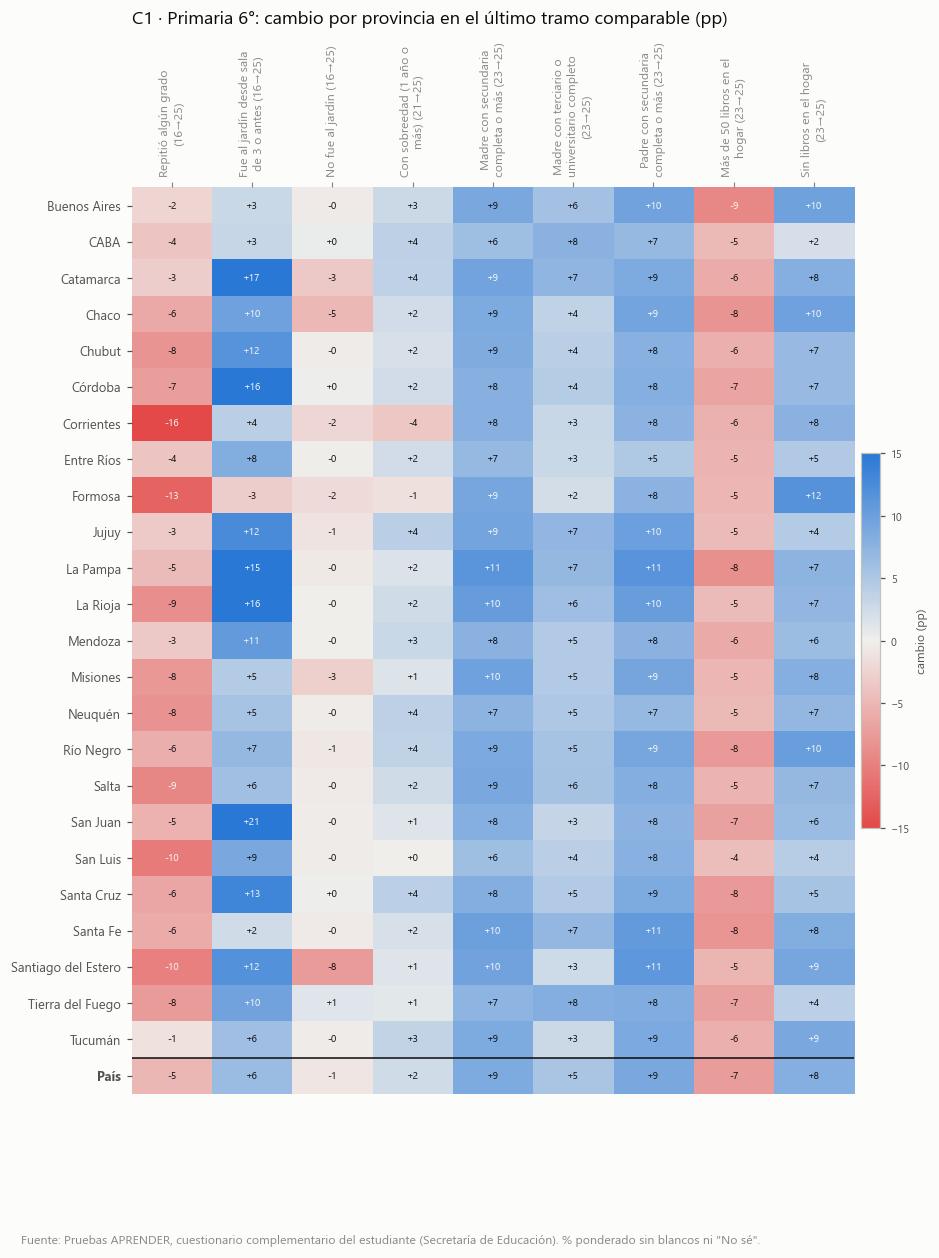

,Repitió algún grado (16→25),Fue al jardín desde sala de 3 o antes (16→25),No fue al jardín (16→25),Con sobreedad (1 año o más) (21→25),Madre con secundaria completa o más (23→25),Madre con terciario o universitario completo (23→25),Padre con secundaria completa o más (23→25),Más de 50 libros en el hogar (23→25),Sin libros en el hogar (23→25)
Buenos Aires,-2.2,2.9,-0.4,2.8,8.9,5.6,9.6,-9.1,9.7
CABA,-3.7,3.1,0.4,3.8,6.1,7.6,6.7,-4.7,1.9
Catamarca,-3.0,17.1,-3.4,3.6,9.5,7.3,8.6,-6.1,8.1
Chaco,-6.2,9.8,-4.8,2.3,8.6,3.5,9.3,-8.1,9.8
Chubut,-8.2,11.6,-0.2,1.8,8.5,4.1,7.8,-5.7,6.7
Córdoba,-7.3,16.2,0.2,2.3,7.9,4.4,8.1,-6.6,6.7
Corrientes,-15.6,4.1,-2.1,-3.5,7.9,3.0,7.6,-5.5,7.7
Entre Ríos,-3.7,8.3,-0.2,2.3,6.8,2.9,4.8,-5.4,4.8
Formosa,-12.6,-3.0,-1.9,-1.3,9.1,2.1,7.6,-5.1,11.7
Jujuy,-3.4,12.4,-1.0,4.0,9.3,7.0,10.0,-4.6,4.5


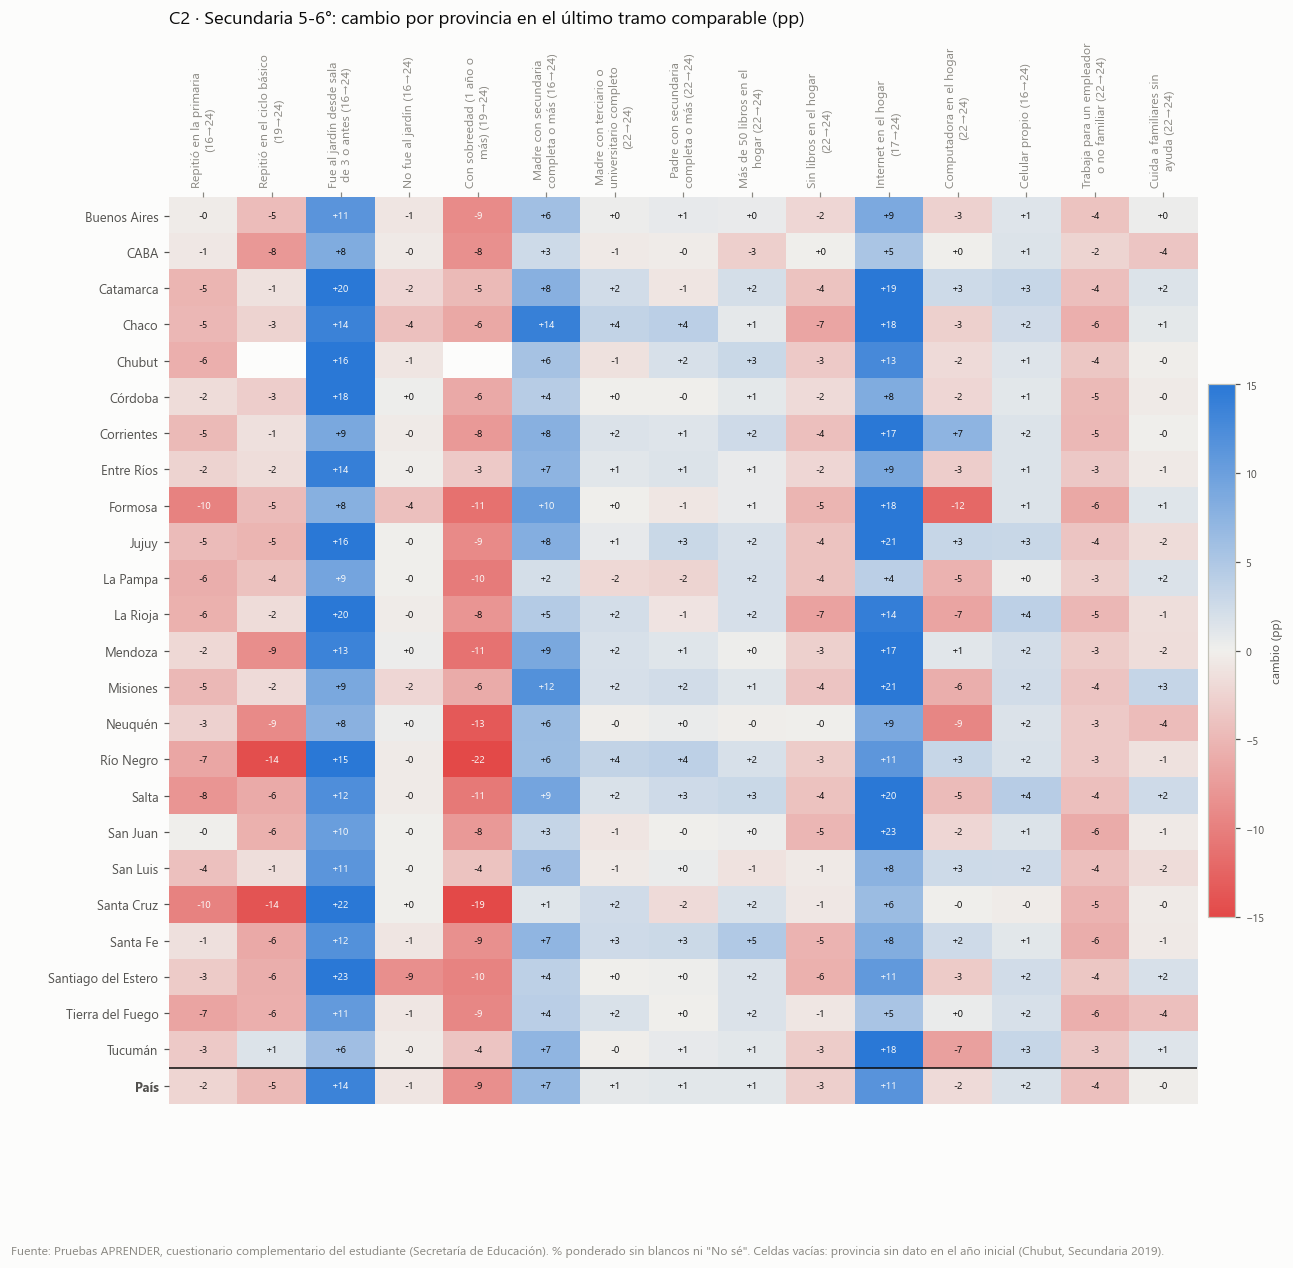

,Repitió en la primaria (16→24),Repitió en el ciclo básico (19→24),Fue al jardín desde sala de 3 o antes (16→24),No fue al jardín (16→24),Con sobreedad (1 año o más) (19→24),Madre con secundaria completa o más (16→24),Madre con terciario o universitario completo (22→24),Padre con secundaria completa o más (22→24),Más de 50 libros en el hogar (22→24),Sin libros en el hogar (22→24),Internet en el hogar (17→24),Computadora en el hogar (22→24),Celular propio (16→24),Trabaja para un empleador o no familiar (22→24),Cuida a familiares sin ayuda (22→24)
Buenos Aires,-0.3,-4.5,11.3,-0.8,-9.0,6.0,0.3,0.7,0.5,-2.1,8.7,-2.6,1.4,-3.9,0.3
CABA,-0.7,-7.8,8.4,-0.5,-8.5,2.6,-0.5,-0.3,-2.9,0.0,5.2,0.0,1.4,-2.4,-3.7
Catamarca,-5.2,-1.2,19.7,-2.1,-4.8,7.8,2.2,-0.9,2.0,-3.9,19.5,2.7,3.1,-4.3,1.5
Chaco,-5.0,-2.6,13.6,-4.1,-6.4,13.9,3.5,3.9,0.7,-6.6,18.3,-2.7,2.4,-5.7,0.9
Chubut,-5.7,NaN,15.8,-0.9,NaN,5.5,-1.2,1.8,2.9,-3.3,12.7,-1.9,1.4,-3.6,-0.2
Córdoba,-1.7,-2.9,17.7,0.2,-6.3,4.3,0.0,-0.0,0.8,-1.8,8.4,-2.1,1.0,-4.7,-0.4
Corrientes,-4.8,-1.4,8.9,-0.4,-7.7,7.8,1.6,1.4,2.5,-4.3,16.7,7.3,1.5,-4.9,-0.1
Entre Ríos,-2.5,-1.6,14.0,-0.1,-3.4,7.4,1.2,1.5,0.5,-2.2,8.9,-2.9,1.4,-3.5,-0.5
Formosa,-9.8,-4.6,7.9,-4.1,-11.3,10.4,0.0,-0.7,0.6,-5.3,17.5,-12.1,1.5,-6.4,1.2
Jujuy,-4.6,-5.2,16.1,-0.0,-9.1,8.2,0.7,2.9,1.8,-4.0,21.3,3.1,3.0,-3.8,-1.7


In [7]:
def ultimo_tramo(coh, nombre):
    """Último tramo comparable (≥ 2 años) si termina en alguno de los dos últimos operativos; si no, None."""
    anios = COHORTES[coh]['anios']
    t = PAIS[(PAIS.cohorte == coh) & (PAIS.indicador == nombre)].set_index('anio').reindex(anios)
    trs = [tr for tr in tramos(list(t.index), [None if pd.isna(v) else v for v in t.redaccion]) if len(tr) >= 2]
    return trs[-1] if trs and trs[-1][-1] in anios[-2:] else None

CAMBIO_PROV, CAMBIO_PAIS = {}, {}
for i, coh in enumerate(COHORTES, start=1):
    cols, paises = {}, {}
    for tema, nombre, _ in IND[coh]:
        tr = ultimo_tramo(coh, nombre)
        if tr is None: continue
        p = POR_PROV[(POR_PROV.cohorte == coh) & (POR_PROV.indicador == nombre)].pivot_table(index='provincia', columns='anio', values='pct')
        etiqueta = f'{nombre} ({str(tr[0])[2:]}→{str(tr[-1])[2:]})'
        cols[etiqueta] = p[tr[-1]] - p[tr[0]]
        n = PAIS[(PAIS.cohorte == coh) & (PAIS.indicador == nombre)].set_index('anio').pct
        paises[etiqueta] = n[tr[-1]] - n[tr[0]]
    c = pd.DataFrame(cols)
    c = c.sort_index(key=lambda i: i.map(_n))
    CAMBIO_PROV[coh], CAMBIO_PAIS[coh] = c, pd.Series(paises, name='País')
    assert len(c) == 24 or coh.startswith('Sec'), coh

    fig, ax = plt.subplots(figsize=(0.62 * c.shape[1] + 3.2, 0.34 * (len(c) + 1) + 2.2))
    m = pd.concat([c, CAMBIO_PAIS[coh].to_frame().T])
    im = ax.imshow(m.values, cmap=DIVERGENTE, norm=TwoSlopeNorm(0, -15, 15), aspect='auto')
    ax.set_xticks(range(m.shape[1])); ax.set_xticklabels([textwrap.fill(x, 26) for x in m.columns], rotation=90, fontsize=8)
    ax.set_yticks(range(len(m))); ax.set_yticklabels(m.index, fontsize=8.5)
    ax.get_yticklabels()[-1].set_fontweight('bold')
    ax.axhline(len(m) - 1.5, color=TINTA, lw=1)
    for (r, q), v in np.ndenumerate(m.values):
        if pd.notna(v):
            ax.text(q, r, f'{v:+.0f}', ha='center', va='center', fontsize=6.5, color=SUPERFICIE if abs(v) > 9 else TINTA)
    ax.grid(False); ax.xaxis.tick_top()
    for s in ax.spines.values(): s.set_visible(False)
    cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01); cb.set_label('cambio (pp)', fontsize=8); cb.ax.tick_params(labelsize=7)
    ax.set_title(f'C{i} · {coh}: cambio por provincia en el último tramo comparable (pp)', loc='left', fontsize=12, pad=12)
    nota(fig, FUENTE_AP + (' Celdas vacías: provincia sin dato en el año inicial (Chubut, Secundaria 2019).' if c.isna().any().any() else ''))
    guardar(fig, f'C{i}_provincias_{"primaria" if i == 1 else "secundaria"}'); plt.show()
    display(m.round(1))

---
## D · Trayectorias en el Relevamiento Anual (2011–2025)
Series de tiempo del sistema completo (no solo de quienes rinden APRENDER). Años de estudio 1 a 12 (1–6 primaria,
7–12 secundaria, homogeneizados por la fuente). **Trayectoria del año *t* = ciclo lectivo *t−1***: repitencia
(`nopromo`), abandono (`ssp`, salidos sin pase) y egresados se muestran por ciclo lectivo. La sobreedad es de la
matrícula del año relevado.

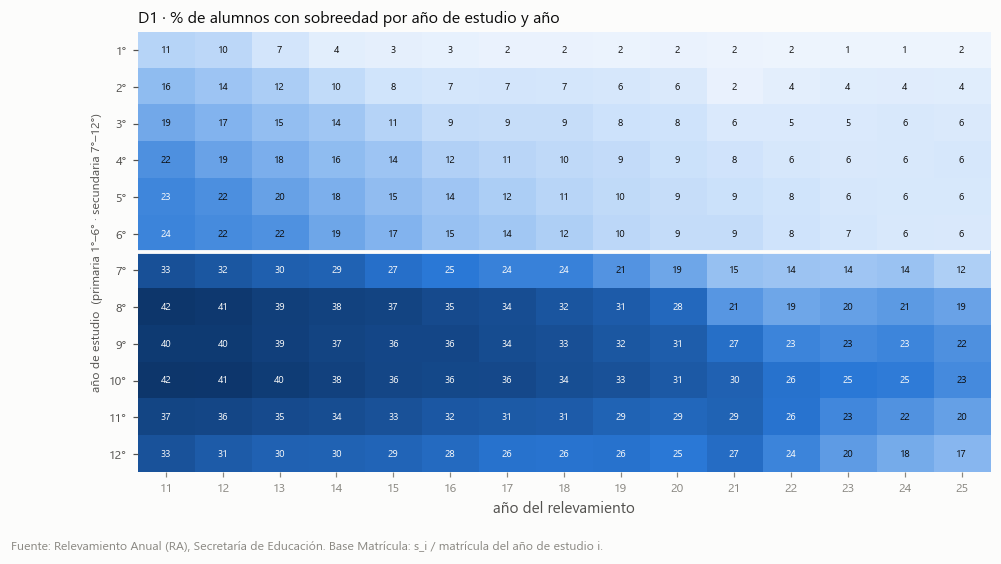

anio,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
1°,11.1,10.3,7.1,3.9,3.2,2.6,2.3,2.3,1.9,2.0,1.8,1.6,1.4,1.4,1.6
2°,15.7,14.0,12.4,9.7,7.6,6.8,7.1,6.8,6.4,5.7,2.4,3.6,4.1,4.4,4.2
3°,18.5,17.1,15.2,13.6,11.2,9.5,9.2,9.2,8.4,7.9,5.5,5.4,5.5,5.9,5.6
4°,21.8,19.5,17.8,15.6,14.0,11.8,10.7,10.1,9.5,8.6,7.8,6.5,5.9,6.0,6.3
5°,23.1,22.0,19.6,17.7,15.5,13.8,12.2,11.0,9.9,9.2,8.6,7.5,6.3,6.1,6.1
6°,23.5,22.5,21.6,18.9,17.1,14.7,13.5,12.0,10.5,9.4,9.3,7.9,6.8,6.0,5.7
7°,33.1,31.9,30.2,29.5,26.8,25.1,23.7,23.8,21.3,18.9,14.8,14.1,13.8,14.3,12.1
8°,41.6,40.8,38.7,37.7,37.0,34.9,34.0,32.1,30.9,28.2,21.1,19.0,19.8,20.6,19.4
9°,40.4,40.4,38.6,37.0,36.3,36.2,34.4,33.4,31.9,30.5,26.9,23.5,22.6,23.4,21.9
10°,41.9,41.5,39.8,37.9,36.3,35.8,35.6,33.8,32.9,31.3,29.6,26.3,25.1,24.6,22.6


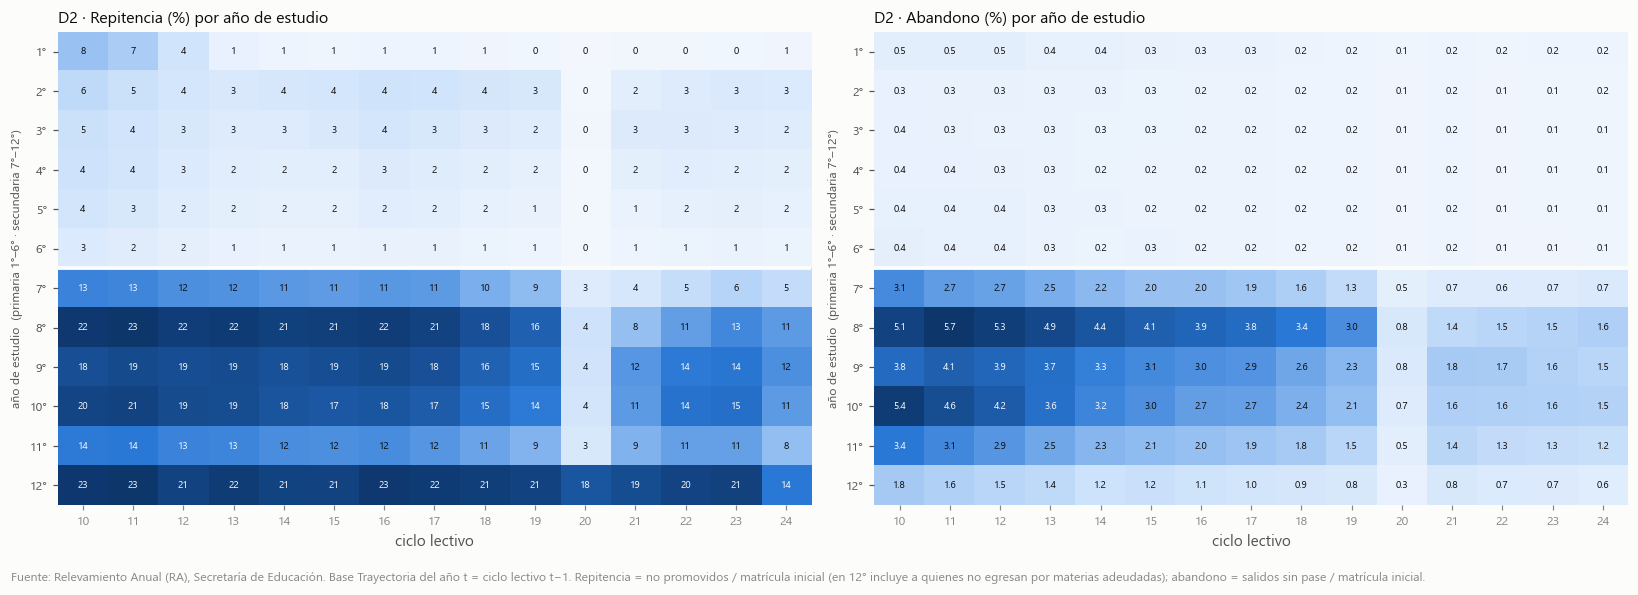

Repitencia por año de estudio (%)


ciclo_lectivo,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1°,8.0,6.9,4.2,1.4,0.9,0.6,0.7,0.7,0.5,0.4,0.2,0.3,0.3,0.4,0.5
2°,5.5,4.8,3.7,3.2,3.6,3.7,4.3,4.2,3.7,3.3,0.2,2.1,2.6,3.0,2.9
3°,4.7,4.1,3.3,2.7,2.7,3.2,3.7,3.3,2.8,2.5,0.3,2.8,2.8,2.7,2.5
4°,4.4,3.8,2.9,2.2,2.0,2.1,2.8,2.5,1.9,1.7,0.2,1.8,2.2,2.1,1.8
5°,3.9,3.3,2.5,1.9,1.7,1.7,2.2,2.0,1.6,1.3,0.2,1.1,1.7,1.7,1.6
6°,2.9,2.4,1.8,1.4,1.2,1.1,1.3,1.3,1.0,0.8,0.3,0.7,1.0,1.1,1.0
7°,13.0,12.7,12.1,11.8,11.4,11.2,11.5,11.3,9.8,8.6,2.6,3.6,5.1,6.1,5.2
8°,22.5,23.0,21.7,22.0,20.9,21.3,21.6,20.7,18.3,16.5,4.5,8.3,10.9,12.7,11.3
9°,18.5,19.4,18.6,19.0,18.2,18.7,19.3,18.3,16.3,14.9,4.3,11.6,13.6,14.0,12.1
10°,20.3,20.6,19.2,18.8,17.8,17.4,17.7,16.9,15.0,13.7,3.9,11.3,14.5,14.7,11.3


Abandono por año de estudio (%)


ciclo_lectivo,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1°,0.5,0.5,0.5,0.4,0.4,0.3,0.3,0.3,0.2,0.2,0.1,0.2,0.2,0.2,0.2
2°,0.3,0.3,0.3,0.3,0.3,0.3,0.2,0.2,0.2,0.2,0.1,0.2,0.1,0.1,0.2
3°,0.4,0.3,0.3,0.3,0.3,0.3,0.2,0.2,0.2,0.2,0.1,0.2,0.1,0.1,0.1
4°,0.4,0.4,0.3,0.3,0.2,0.2,0.2,0.2,0.2,0.2,0.1,0.2,0.1,0.1,0.1
5°,0.4,0.4,0.4,0.3,0.3,0.2,0.2,0.2,0.2,0.2,0.1,0.2,0.1,0.1,0.1
6°,0.4,0.4,0.4,0.3,0.2,0.3,0.2,0.2,0.2,0.2,0.1,0.2,0.1,0.1,0.1
7°,3.1,2.7,2.7,2.5,2.2,2.0,2.0,1.9,1.6,1.3,0.5,0.7,0.6,0.7,0.7
8°,5.1,5.7,5.3,4.9,4.4,4.1,3.9,3.8,3.4,3.0,0.8,1.4,1.5,1.5,1.6
9°,3.8,4.1,3.9,3.7,3.3,3.1,3.0,2.9,2.6,2.3,0.8,1.8,1.7,1.6,1.5
10°,5.4,4.6,4.2,3.6,3.2,3.0,2.7,2.7,2.4,2.1,0.7,1.6,1.6,1.6,1.5


In [8]:
def cargar_ra(base):
    return pd.read_parquet(os.path.join(OUT, 'ra', f'ra_{base}.parquet'))
def num(df, cols):
    return df[cols].apply(pd.to_numeric, errors='coerce').astype('float64').fillna(0)

MAT, TRA = cargar_ra('matricula'), cargar_ra('trayectoria')
AE = list(range(1, 13)); PRIM, SEC = range(1, 7), range(7, 13)
ETQ_AE = [f'{i}°' for i in AE]   # años de estudio homogeneizados: 1°–6° primaria, 7°–12° secundaria

def por_anio(df, prefijo, anios_estudio, por='anio'):
    cols = [f'{prefijo}_{i}' for i in anios_estudio]
    return num(df, cols).groupby(df[por] if isinstance(por, str) else [df[p] for p in por]).sum().set_axis(list(anios_estudio), axis=1)

# D1 · sobreedad por año de estudio (matrícula del año)
SOBREEDAD_AE = 100 * por_anio(MAT, 's', AE) / por_anio(MAT, '', AE)
# D2 · repitencia y abandono por año de estudio (ciclo lectivo = año − 1)
ini = por_anio(TRA, 'inicial', AE)
REPITENCIA_AE = (100 * por_anio(TRA, 'nopromo', AE) / ini).rename(index=lambda a: a - 1)
ABANDONO_AE = (100 * por_anio(TRA, 'ssp', AE) / ini).rename(index=lambda a: a - 1)
for t in (REPITENCIA_AE, ABANDONO_AE): t.index.name = 'ciclo_lectivo'
SOBREEDAD_AE.index.name = 'anio'

def mapa_calor(ax, t, titulo, fmt='{:.0f}', vmax=None):
    m = t.T.values
    im = ax.imshow(m, cmap=SECUENCIAL, aspect='auto', vmin=0, vmax=vmax or np.nanmax(m))
    ax.set_xticks(range(t.shape[0])); ax.set_xticklabels([str(a)[2:] for a in t.index], fontsize=8)
    ax.set_yticks(range(t.shape[1])); ax.set_yticklabels(ETQ_AE if t.shape[1] == 12 else t.columns, fontsize=8)
    lim = (vmax or np.nanmax(m)) * 0.55
    for (r, q), v in np.ndenumerate(m):
        ax.text(q, r, fmt.format(v), ha='center', va='center', fontsize=6.5, color=SUPERFICIE if v > lim else TINTA)
    ax.axhline(5.5, color=SUPERFICIE, lw=2.5)
    ax.grid(False); ax.set_title(titulo, loc='left', fontsize=10.5)
    ax.set_ylabel('año de estudio  (primaria 1°–6° · secundaria 7°–12°)', fontsize=8)
    for s in ax.spines.values(): s.set_visible(False)
    return im

fig, ax = plt.subplots(figsize=(10, 5.2))
mapa_calor(ax, SOBREEDAD_AE, 'D1 · % de alumnos con sobreedad por año de estudio y año')
ax.set_xlabel('año del relevamiento')
nota(fig, FUENTE_RA + ' Base Matrícula: s_i / matrícula del año de estudio i.')
guardar(fig, 'D1_ra_sobreedad_anio_estudio'); plt.show()
display(SOBREEDAD_AE.T.set_axis(ETQ_AE).round(1))

fig, axs = plt.subplots(1, 2, figsize=(15, 5.2))
mapa_calor(axs[0], REPITENCIA_AE, 'D2 · Repitencia (%) por año de estudio', fmt='{:.0f}')
mapa_calor(axs[1], ABANDONO_AE, 'D2 · Abandono (%) por año de estudio', fmt='{:.1f}')
for ax in axs: ax.set_xlabel('ciclo lectivo')
fig.tight_layout()
nota(fig, FUENTE_RA + ' Base Trayectoria del año t = ciclo lectivo t−1. Repitencia = no promovidos / matrícula inicial (en 12° incluye a quienes no egresan por materias adeudadas); abandono = salidos sin pase / matrícula inicial.')
guardar(fig, 'D2_ra_repitencia_abandono_anio_estudio'); plt.show()
print('Repitencia por año de estudio (%)'); display(REPITENCIA_AE.T.set_axis(ETQ_AE).round(1))
print('Abandono por año de estudio (%)'); display(ABANDONO_AE.T.set_axis(ETQ_AE).round(1))

Egresados de primaria: ciclos excluidos por provincias sin dato (0 egresados):

 {2010: 5, 2011: 2, 2012: 1}
Egresados de secundaria: ciclos excluidos por provincias sin dato (0 egresados): ninguno


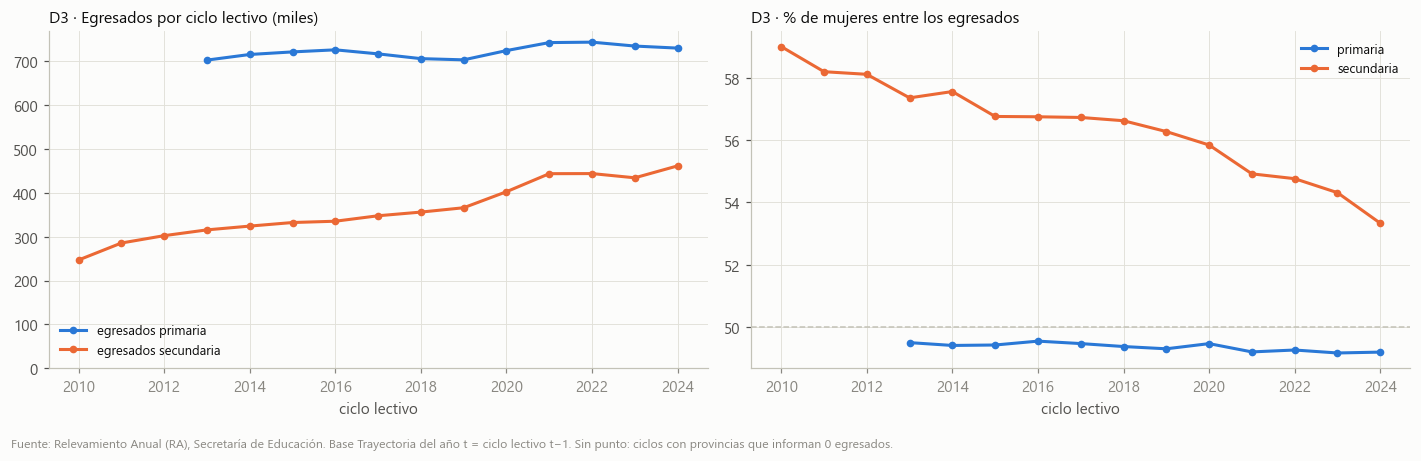

,egresados primaria (miles),egresados secundaria (miles),% mujeres · primaria,% mujeres · secundaria
ciclo_lectivo,,,,
2010,NaN,247.0,NaN,59.0
2011,NaN,285.7,NaN,58.2
2012,NaN,302.5,NaN,58.1
2013,702.8,315.7,49.5,57.4
2014,715.6,324.3,49.4,57.6
2015,721.5,332.4,49.4,56.8
2016,726.3,335.4,49.5,56.7
2017,717.0,347.8,49.5,56.7
2018,706.2,356.2,49.4,56.6


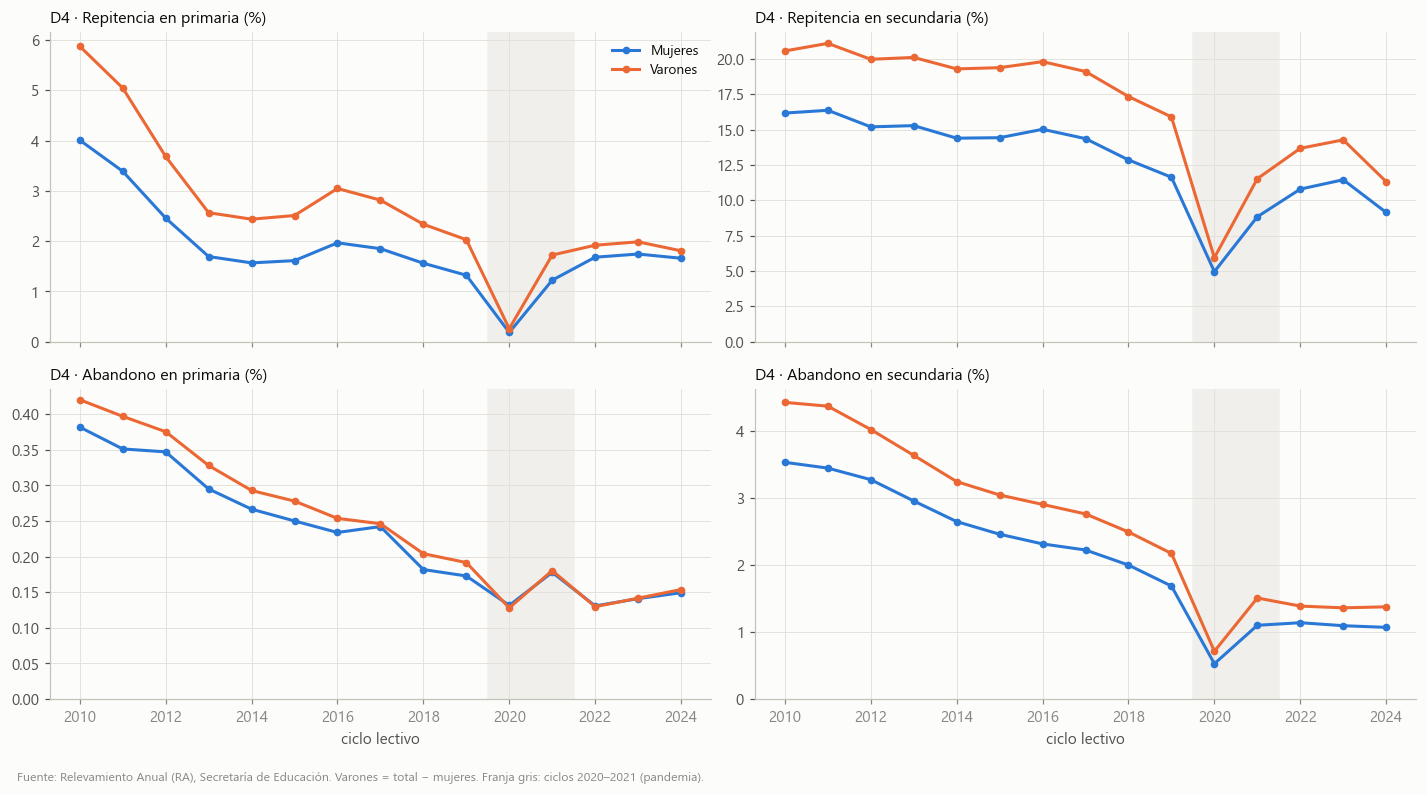

Repitencia primaria         Repitencia secundaria          \
                          Mujeres Varones               Mujeres Varones   
ciclo_lectivo                                                             
2010                         4.01    5.87                 16.17   20.56   
2011                         3.39    5.04                 16.36   21.09   
2012                         2.46    3.68                 15.19   19.97   
2013                         1.69    2.56                 15.28   20.10   
2014                         1.57    2.44                 14.39   19.29   
2015                         1.61    2.51                 14.42   19.38   
2016                         1.97    3.05                 15.02   19.80   
2017                         1.85    2.81                 14.36   19.11   
2018                         1.56    2.33                 12.85   17.33   
2019                         1.32    2.03                 11.63   15.90   
2020                         0.18    0.26                  4.95    5.94   
2021                         1.22    1.72                  8.83   11.52   
2022                         1.68    1.92                 10.79   13.67   
2023                         1.74    1.98                 11.45   14.27   
2024                         1.66    1.81                  9.14   11.31   

              Abandono primaria         Abandono secundaria          
                        Mujeres Varones             Mujeres Varones  
ciclo_lectivo                                                        
2010                       0.38    0.42                3.53    4.42  
2011                       0.35    0.40                3.44    4.36  
2012                       0.35    0.38                3.27    4.01  
2013                       0.29    0.33                2.95    3.63  
2014                       0.27    0.29                2.64    3.24  
2015                       0.25    0.28                2.45    3.04  
2016                       0.23    0.25                2.31    2.90  
2017                       0.24    0.25                2.22    2.76  
2018                       0.18    0.20                2.00    2.49  
2019                       0.17    0.19                1.68    2.17  
2020                       0.13    0.13                0.53    0.71  
2021                       0.18    0.18                1.10    1.50  
2022                       0.13    0.13                1.14    1.38  
2023                       0.14    0.14                1.09    1.36  
2024                       0.15    0.15                1.07    1.37

In [9]:
# D3 · egresados por ciclo lectivo y % de mujeres
cols_eg = ['primaria_egresados', 'primaria_m_egresados', 'secundaria_egresados', 'secundaria_m_egresados']
eg_prov = num(TRA, cols_eg).assign(anio=TRA.anio, provincia=TRA.provincia.map(norm_prov)).groupby(['anio', 'provincia']).sum()
eg = eg_prov.groupby('anio').sum()
# Cobertura: en los primeros relevamientos varias provincias informan 0 egresados → ese ciclo no es comparable
sin_dato = {niv: (eg_prov[f'{niv}_egresados'] == 0).groupby('anio').sum() for niv in ['primaria', 'secundaria']}
eg.index = eg.index - 1; eg.index.name = 'ciclo_lectivo'
EGRESADOS = pd.DataFrame({
    'egresados primaria (miles)': eg.primaria_egresados / 1e3, 'egresados secundaria (miles)': eg.secundaria_egresados / 1e3,
    '% mujeres · primaria': 100 * eg.primaria_m_egresados / eg.primaria_egresados,
    '% mujeres · secundaria': 100 * eg.secundaria_m_egresados / eg.secundaria_egresados})
for niv in ['primaria', 'secundaria']:
    malos = [a - 1 for a, n in sin_dato[niv].items() if n > 0]
    EGRESADOS.loc[malos, [f'egresados {niv} (miles)', f'% mujeres · {niv}']] = np.nan
    print(f'Egresados de {niv}: ciclos excluidos por provincias sin dato (0 egresados):',
          {a - 1: int(n) for a, n in sin_dato[niv].items() if n > 0} or 'ninguno')

# D4 · brecha mujeres / varones en repitencia y abandono (por nivel)
def tasa_sexo(prefijo, rango):
    tot, muj = por_anio(TRA, prefijo, rango).sum(axis=1), por_anio(TRA, f'm_{prefijo}', rango).sum(axis=1)
    it, im_ = por_anio(TRA, 'inicial', rango).sum(axis=1), por_anio(TRA, 'm_inicial', rango).sum(axis=1)
    out = pd.DataFrame({'Mujeres': 100 * muj / im_, 'Varones': 100 * (tot - muj) / (it - im_)})
    out.index = out.index - 1; out.index.name = 'ciclo_lectivo'
    return out
GENERO = {(ind, niv): tasa_sexo(p, r) for ind, p in [('Repitencia', 'nopromo'), ('Abandono', 'ssp')]
          for niv, r in [('primaria', PRIM), ('secundaria', SEC)]}

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
for col, c in [('egresados primaria (miles)', AZUL), ('egresados secundaria (miles)', NARANJA)]:
    axs[0].plot(EGRESADOS.index, EGRESADOS[col], color=c, lw=2, marker='o', ms=4, label=col.replace(' (miles)', ''))
for col, c in [('% mujeres · primaria', AZUL), ('% mujeres · secundaria', NARANJA)]:
    axs[1].plot(EGRESADOS.index, EGRESADOS[col], color=c, lw=2, marker='o', ms=4, label=col.replace('% mujeres · ', ''))
axs[0].set_title('D3 · Egresados por ciclo lectivo (miles)', loc='left', fontsize=10.5); axs[0].set_ylim(0)
axs[1].set_title('D3 · % de mujeres entre los egresados', loc='left', fontsize=10.5); axs[1].axhline(50, color=EJE, lw=1, ls='--')
for ax in axs: ax.legend(frameon=False, fontsize=8.5); ax.set_xlabel('ciclo lectivo')
fig.tight_layout(); nota(fig, FUENTE_RA + ' Base Trayectoria del año t = ciclo lectivo t−1. Sin punto: ciclos con provincias que informan 0 egresados.')
guardar(fig, 'D3_ra_egresados'); plt.show()
display(EGRESADOS.round(1))

fig, axs = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for ax, ((ind, niv), t) in zip(axs.flat, GENERO.items()):
    for col, c in [('Mujeres', AZUL), ('Varones', NARANJA)]:
        ax.plot(t.index, t[col], color=c, lw=2, marker='o', ms=4, label=col)
    ax.set_title(f'D4 · {ind} en {niv} (%)', loc='left', fontsize=10.5); ax.set_ylim(0)
    ax.axvspan(2019.5, 2021.5, color=NEUTRO, zorder=0)
axs[0, 0].legend(frameon=False, fontsize=9)
for ax in axs[1]: ax.set_xlabel('ciclo lectivo')
fig.tight_layout(); nota(fig, FUENTE_RA + ' Varones = total − mujeres. Franja gris: ciclos 2020–2021 (pandemia).')
guardar(fig, 'D4_ra_genero'); plt.show()
display(pd.concat({f'{ind} {niv}': t for (ind, niv), t in GENERO.items()}, axis=1).round(2))

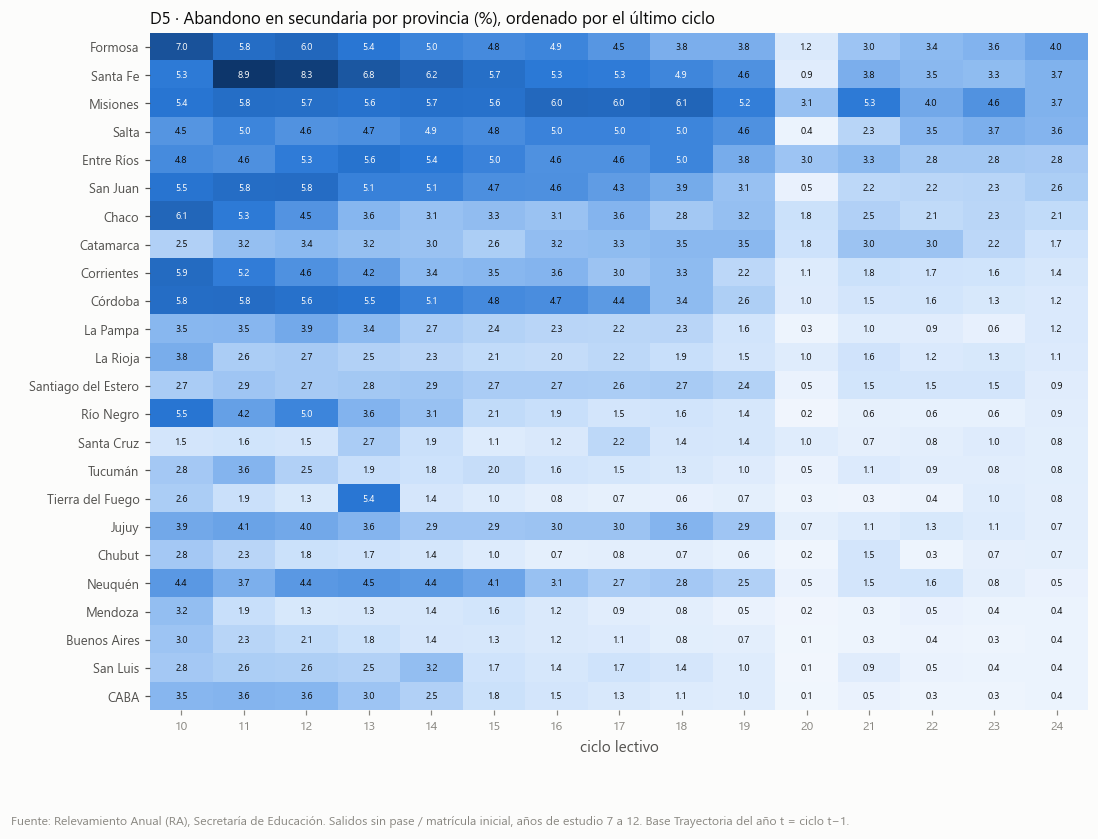

Sobreedad en secundaria por provincia (% , matrícula del año)


anio,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
provincia,,,,,,,,,,,,,,,
Buenos Aires,37.4,37.8,35.0,33.9,32.5,31.7,30.7,29.8,28.5,26.1,23.3,21.1,19.9,20.0,15.5
CABA,28.3,29.4,28.5,27.1,26.4,25.3,24.6,22.4,21.4,20.4,18.4,15.5,14.2,14.3,13.2
Catamarca,36.8,38.1,35.2,33.0,32.0,31.0,29.6,31.1,30.6,29.7,28.3,24.5,22.6,21.6,21.9
Chaco,43.9,32.5,40.5,37.9,35.3,31.1,31.2,30.6,29.9,29.7,28.4,25.5,22.1,21.6,23.0
Chubut,43.9,44.7,42.8,41.6,39.8,36.8,35.6,31.8,30.7,27.1,27.6,26.8,25.2,23.6,23.7
Corrientes,46.8,48.2,46.9,45.6,43.6,42.5,41.9,42.0,41.5,39.9,38.8,34.7,32.9,33.1,32.2
Córdoba,35.6,32.9,30.1,28.7,27.9,26.9,25.0,24.2,23.1,22.4,21.4,18.7,18.3,18.1,17.5
Entre Ríos,42.2,41.5,41.6,41.4,39.1,37.8,36.9,35.2,34.4,33.3,35.4,31.2,30.1,30.6,29.5
Formosa,47.8,44.3,41.0,42.2,39.1,38.3,38.0,36.5,35.4,34.0,34.7,29.9,28.4,28.2,29.1


In [10]:
# D5 · abandono y sobreedad en secundaria por provincia
prov_tra = TRA.assign(provincia=TRA.provincia.map(norm_prov))
ab = por_anio(prov_tra, 'ssp', SEC, por=['provincia', 'anio']).sum(axis=1) / por_anio(prov_tra, 'inicial', SEC, por=['provincia', 'anio']).sum(axis=1)
AB_PROV = (100 * ab).unstack('anio').rename(columns=lambda a: a - 1)
prov_mat = MAT.assign(provincia=MAT.provincia.map(norm_prov))
so = por_anio(prov_mat, 's', SEC, por=['provincia', 'anio']).sum(axis=1) / por_anio(prov_mat, '', SEC, por=['provincia', 'anio']).sum(axis=1)
SOB_PROV = (100 * so).unstack('anio')
assert len(AB_PROV) == 24 and len(SOB_PROV) == 24
AB_PROV = AB_PROV.loc[AB_PROV[AB_PROV.columns[-1]].sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 8))
m = AB_PROV.values
im = ax.imshow(m, cmap=SECUENCIAL, aspect='auto', vmin=0, vmax=np.nanmax(m))
ax.set_xticks(range(m.shape[1])); ax.set_xticklabels([str(a)[2:] for a in AB_PROV.columns], fontsize=8)
ax.set_yticks(range(len(AB_PROV))); ax.set_yticklabels(AB_PROV.index, fontsize=8.5)
for (r, q), v in np.ndenumerate(m):
    ax.text(q, r, f'{v:.1f}', ha='center', va='center', fontsize=6.3, color=SUPERFICIE if v > np.nanmax(m) * 0.55 else TINTA)
ax.grid(False); ax.set_xlabel('ciclo lectivo')
for s in ax.spines.values(): s.set_visible(False)
ax.set_title('D5 · Abandono en secundaria por provincia (%), ordenado por el último ciclo', loc='left', fontsize=11)
nota(fig, FUENTE_RA + ' Salidos sin pase / matrícula inicial, años de estudio 7 a 12. Base Trayectoria del año t = ciclo t−1.')
guardar(fig, 'D5_ra_abandono_secundaria_provincias'); plt.show()
print('Sobreedad en secundaria por provincia (% , matrícula del año)')
display(SOB_PROV.round(1))

---
## E · Lectura de resultados (corrida 2026-09-16)

**Criterio general.** Un cambio que aparece **parejo en las 24 provincias** entre dos operativos seguidos suele indicar un
cambio del cuestionario más que del contexto real (lo mismo se vio en el 03). Los cambios que difieren entre provincias,
sectores o ámbitos, o que se sostienen en varios operativos, son más confiables.

**1. Trayectoria: menos repitencia y sobreedad, más jardín desde sala de 3.**
- Repitencia declarada en Primaria 6°: 12,1 % (2016) → 7,1 % (2025), baja en las 24 provincias. 2023 (12,8 %) es un
  valor atípico: la opción "tres veces o más" pesa 2,1 %, contra ≈ 0,5 % en los demás años. En Secundaria, quienes
  repitieron en la primaria bajan de 7,8 % a 5,5 % (2016 → 2024) y en el ciclo básico de 13,1 % a 8,3 % (2019 → 2024).
- Sobreedad en Secundaria 5-6°: 26,3 % → 17,7 % (2019 → 2024), baja en todas las provincias con dato (Río Negro −22 pp).
  El RA muestra lo mismo en todo el sistema: la sobreedad de 7° a 12° año cae a la mitad entre 2011 y 2025 (p. ej.,
  10° año: 41,9 % → 22,6 %) y la de 6° grado pasa de 23,5 % a 5,8 %. **Discrepancia:** en Primaria 6°, la sobreedad de
  APRENDER sube (10,2 % → 12,5 %, 2021 → 2025) mientras la del RA baja; conviene no usar ese indicador de APRENDER hasta
  entender cómo se calcula la edad en 2025.
- Jardín desde sala de 3 o antes: Secundaria 43,4 % (2016) → 57,0 % (2024), sube en las 24 provincias; Primaria 55,0 % →
  61,4 %. **Control de coherencia:** la cohorte de nacimiento de ≈ 2005 responde casi lo mismo en Primaria 2016 (55,0 %) y
  en Secundaria 2022 (55,5 %), seis años después. La brecha urbano−rural se mantiene en ≈ 19–23 pp.

**2. Hogar: mejora el nivel educativo de las familias; libros con cambios de cuestionario.**
- Madre con secundaria completa o más: Secundaria 59,9 % → 66,6 % (2016 → 2024), sube en las 24 provincias. La brecha
  privado−estatal baja de 28,7 a 25,4 pp y la urbano−rural de 26,4 a 21,5 pp.
- En Primaria, el salto 2023 → 2025 (66,2 % → 74,8 %) es **parejo en las 24 provincias** (+6 a +11 pp), igual que la
  caída de "más de 50 libros" (−4 a −9 pp en todas) y la suba de "sin libros" (+2 a +12 pp en todas). Probablemente
  refleja el cuestionario renumerado de 2025: **no leerlo como un cambio real** sin el cuestionario oficial.
- Libros: la serie se corta cuando cambian las opciones. Hasta 2019/2021 existía "No sé" (17–24 %), y después no. En
  Secundaria, "más de 50 libros" pasa de 41,8 % (2019) a 21,9 % (2022), un salto de medición y no de contexto.

**3. Acceso digital: internet casi universal; la computadora retrocede y se amplía la brecha por sector.**
- Internet en el hogar: Secundaria 84,1 % (2017) → 95,5 % (2024), sube en las 24 provincias (San Juan +23 pp); la
  brecha urbano−rural se achica de 23,6 a 9,9 pp. Primaria: 62,7 % (2016) → 80,5 % (2018) y 91,9 % (2023).
- Computadora en el hogar: Secundaria 85,7 % (2017) → 73,5 % (2024); Primaria 76,2 % (2018) → 61,8 % (2023). La brecha
  **privado−estatal se amplía**: de 13,2 a 21,6 pp en Secundaria y de 20,5 a 29,3 pp en Primaria. En Secundaria
  2022 → 2024 cae en 15 provincias (Formosa −12 pp).
- Celular propio: ≈ 96–97 % en Secundaria desde 2016; en Primaria 75,9 % (2016) → 90,9 % (2023).

**4. Trabajo y cuidados: preguntas poco comparables entre años; señales parciales.**
- Secundaria: trabajar para un empleador la semana pasada baja de 19,7 % a 15,6 % (2022 → 2024) **en las 24 provincias**
  (−2 a −6 pp); cuidar familiares sin ayuda se mantiene (39,6 % → 39,5 %).
- Ayudar en el trabajo de familiares es ≈ 12–22 pp más frecuente en el ámbito rural, en ambas cohortes y todos los años.
- En Primaria las cuatro mediciones usan períodos distintos (la semana pasada / habitualmente / frecuencia) y **no forman
  una serie**; 2025 no tiene una pregunta identificable.

**5. RA: menos abandono, varones más rezagados y más egresados de secundaria.**
- Abandono en secundaria: mujeres 3,5 % → 1,1 % y varones 4,4 % → 1,4 % (ciclos 2010 → 2024). Repitencia en secundaria:
  varones 20,6 % → 11,3 % y mujeres 16,2 % → 9,1 %. Los varones repiten y abandonan más en todos los ciclos. Los ciclos
  2020–2021 (promoción acompañada) no son comparables.
- Egresados de secundaria: 247 mil (ciclo 2010) → 462 mil (2024). La proporción de mujeres baja de 59,0 % a 53,3 %: los
  varones reducen la brecha de terminalidad. Los egresados de primaria de 2010–2012 se excluyen porque varias provincias
  informan 0.
- Abandono en secundaria por provincia (ciclo 2024): más alto en Formosa (4,0 %), Santa Fe y Misiones (3,7 %) y Salta
  (3,6 %); 0,4 % en CABA, Buenos Aires, Mendoza y San Luis. En Santa Fe el abandono vuelve a subir (3,3 % en 2023 → 3,7 %
  en 2024) y la sobreedad secundaria también (18,8 % → 23,0 %, 2023 → 2025).
- **Control de calidad:** la sobreedad secundaria de Santa Cruz salta de 6,5 % (2024) a 17,6 % (2025) tras bajar de 51 %
  a 6,5 % en 2011–2024: revisar antes de usar esa provincia.

**Qué no se puede afirmar.** Son descripciones de agregados: no permiten atribuir cambios de desempeño a estos factores
(sin econometría) y, en APRENDER, solo describen a quienes rinden la prueba (en Secundaria, a quienes llegaron al último
año).

---
## F · Descargar gráficos y tablas
Guarda todas las tablas en `contexto_estudiantes.xlsx` dentro de `graficos_contexto/`, comprime la carpeta en un `.zip`
y, en **Colab**, **lo descarga**.

In [11]:
hojas = {'preguntas_por_anio': PREGUNTAS.set_index(['cohorte', 'tema', 'indicador', 'anio'])}
for nombre, t, por in [('pais', PAIS, None), ('sector', POR_SECTOR, 'sector'), ('ambito', POR_AMBITO, 'ambito'), ('provincias', POR_PROV, 'provincia')]:
    idx = ['cohorte', 'orden', 'tema', 'indicador'] + ([por] if por else [])
    hojas[nombre] = t.pivot_table(index=idx, columns='anio', values='pct').droplevel('orden')
for col, br in BRECHAS.items():
    v = br.columns[-1]
    hojas[f'brecha_{col}'] = br.pivot_table(index=['cohorte', 'orden', 'tema', 'indicador'], columns='anio', values=v).droplevel('orden')
for coh, suf in [('Primaria 6°', 'prim'), ('Secundaria 5-6°', 'sec')]:
    hojas[f'cambio_provincias_{suf}'] = pd.concat([CAMBIO_PROV[coh], CAMBIO_PAIS[coh].to_frame().T])
hojas['ra_sobreedad_anio_estudio'] = SOBREEDAD_AE.T.set_axis(ETQ_AE)
hojas['ra_repitencia_anio_estudio'] = REPITENCIA_AE.T.set_axis(ETQ_AE)
hojas['ra_abandono_anio_estudio'] = ABANDONO_AE.T.set_axis(ETQ_AE)
hojas['ra_egresados'] = EGRESADOS
hojas['ra_genero'] = pd.concat({f'{ind} {niv}': t for (ind, niv), t in GENERO.items()}, axis=1)
hojas['ra_abandono_sec_provincias'] = AB_PROV
hojas['ra_sobreedad_sec_provincias'] = SOB_PROV
ruta_xlsx = os.path.join(GRAF, 'contexto_estudiantes.xlsx')
with pd.ExcelWriter(ruta_xlsx, engine='openpyxl') as xw:
    for nombre, t in hojas.items():
        t = t.copy()
        if isinstance(t.columns, pd.MultiIndex):
            t.columns = [' | '.join(map(str, c)) for c in t.columns]
        num_cols = t.select_dtypes('number').columns
        t[num_cols] = t[num_cols].round(3)
        t.to_excel(xw, sheet_name=nombre[:31])
print('Archivos a descargar:')
for n in sorted(os.listdir(GRAF)): print('  -', n)
zip_path = shutil.make_archive(os.path.join(os.path.dirname(GRAF), 'graficos_contexto'), 'zip', GRAF)
print('\nZIP:', zip_path, f'({os.path.getsize(zip_path)/1e6:.1f} MB)')
if in_colab():
    from google.colab import files
    files.download(zip_path)
    print('Descargando el zip...')
else:
    print('Entorno local: los archivos quedan en', GRAF)

Archivos a descargar:
  - A1_pais_primaria.png
  - A2_pais_secundaria.png
  - B1_sector_primaria.png
  - B2_sector_secundaria.png
  - B3_ambito_primaria.png
  - B4_ambito_secundaria.png
  - C1_provincias_primaria.png
  - C2_provincias_secundaria.png
  - D1_ra_sobreedad_anio_estudio.png
  - D2_ra_repitencia_abandono_anio_estudio.png
  - D3_ra_egresados.png
  - D4_ra_genero.png
  - D5_ra_abandono_secundaria_provincias.png
  - contexto_estudiantes.xlsx

ZIP: C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\graficos_contexto.zip (5.3 MB)
Entorno local: los archivos quedan en C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\graficos_contexto
